<a href="https://colab.research.google.com/github/Rene-Twizerimana/IFRS9-ECL-Rwandan-Bank/blob/main/DESSERTATION_ML_MODEL_FOR_LYDIA_APRIL_UPDATES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PREPROCESSING**

In [141]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera, shapiro
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import cross_val_score, TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [142]:
DATA_PATH = '/content/Rwanda_Economy_Dataset_Final.csv'
OUTPUT_DIR = '/content/outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values('Date').reset_index(drop=True)

print(f"Shape     : {df.shape}")
print(f"Period    : {df['Date'].min().year} – {df['Date'].max().year}")
print(f"Missing   : {df.isnull().sum().sum()}")
print(f"Columns   : {df.columns.tolist()}")

Shape     : (261, 15)
Period    : 1960 – 2025
Missing   : 529
Columns   : ['Quarter_ID', 'Quarter_Period', 'Date', 'Year', 'Quarter', 'Foreign_Direct_Investment_Net_Inflows_Percent_GDP', 'Unemployment_Total_Percent_Labor_Force', 'Broad_Money_Percent_GDP', 'Official_Exchange_Rate_LCU_per_USD', 'GDP_Deflator', 'GDP_Current_USD', 'Lending_Interest_Rate_Percent', 'Deposit_Interest_Rate_Percent', 'Interest_Spread_Percent', 'index']


# **MISSING VALUES AUDIT**

In [143]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Pct', ascending=False)
print(missing_df)

                                                   Missing    Pct
Unemployment_Total_Percent_Labor_Force                 124  47.51
Lending_Interest_Rate_Percent                          120  45.98
Interest_Spread_Percent                                120  45.98
Deposit_Interest_Rate_Percent                          120  45.98
Foreign_Direct_Investment_Net_Inflows_Percent_GDP       44  16.86
Broad_Money_Percent_GDP                                  1   0.38


# **FEATURE ENGENERIING**

In [144]:

from scipy.stats.mstats import winsorize

# Core rates
df['Inflation_QoQ']       = df['GDP_Deflator'].pct_change() * 100
df['Real_GDP_Growth_QoQ'] = df['GDP_Current_USD'].pct_change() * 100
df['D_Exchange_Rate']     = df['Official_Exchange_Rate_LCU_per_USD'].pct_change() * 100
df['Log_GDP']             = np.log(df['GDP_Current_USD'])

# Clip extreme values BEFORE creating lags
df['Inflation_QoQ']       = df['Inflation_QoQ'].clip(-50, 50)
df['Real_GDP_Growth_QoQ'] = df['Real_GDP_Growth_QoQ'].clip(-30, 30)
df['D_Exchange_Rate']     = df['D_Exchange_Rate'].clip(-50, 50)

# Lags
for lag in [1, 2, 3, 4]:
    df[f'inflation_lag{lag}'] = df['Inflation_QoQ'].shift(lag)
    df[f'gdp_lag{lag}']       = df['Real_GDP_Growth_QoQ'].shift(lag)

# Nonlinear + regime features
df['inflation_squared'] = df['Inflation_QoQ'] ** 2
df['post_genocide']     = (df['Year'] >= 1995).astype(int)

print(f"Shape : {df.shape}")
print(df[['Inflation_QoQ', 'Real_GDP_Growth_QoQ', 'D_Exchange_Rate']].describe().round(2))

Shape : (261, 29)
       Inflation_QoQ  Real_GDP_Growth_QoQ  D_Exchange_Rate
count         260.00               260.00           260.00
mean            0.90                 2.39             2.06
std            20.96                 5.94             7.30
min           -50.00               -30.00            -9.25
25%            -5.24                 0.10            -1.04
50%             1.22                 1.90             0.97
75%             7.99                 4.34             3.62
max            50.00                30.00            50.00


In [145]:
PRE_FEATURES = [
    'Inflation_QoQ', 'inflation_lag1', 'inflation_lag2',
    'gdp_lag1', 'gdp_lag2',
    'Broad_Money_Percent_GDP', 'D_Exchange_Rate',
    'inflation_squared'
]

POST_FEATURES = PRE_FEATURES + [
    'Foreign_Direct_Investment_Net_Inflows_Percent_GDP',
    'Lending_Interest_Rate_Percent',
    'Unemployment_Total_Percent_Labor_Force'
]

TARGET = 'Real_GDP_Growth_QoQ'

pre_df  = df[(df['Year'] >= 1960) & (df['Year'] <= 1993)].dropna(subset=PRE_FEATURES  + [TARGET]).copy()
post_df = df[(df['Year'] >= 1995) & (df['Year'] <= 2024)].dropna(subset=POST_FEATURES + [TARGET]).copy()

for col in ['Inflation_QoQ', 'Real_GDP_Growth_QoQ']:
    pre_df[col]  = winsorize(pre_df[col],  limits=[0.025, 0.025])
    post_df[col] = winsorize(post_df[col], limits=[0.025, 0.025])

print(f"Pre-genocide  samples : {len(pre_df)}")
print(f"Post-genocide samples : {len(post_df)}")
print(f"\nPre  GDP Growth: min={pre_df[TARGET].min():.2f}  max={pre_df[TARGET].max():.2f}")
print(f"Post GDP Growth: min={post_df[TARGET].min():.2f}  max={post_df[TARGET].max():.2f}")

Pre-genocide  samples : 133
Post-genocide samples : 120

Pre  GDP Growth: min=-6.59  max=15.42
Post GDP Growth: min=-1.14  max=13.54


# **HANDLING MISSING VALUES**

In [146]:
df = df.sort_values("Date").reset_index(drop=True)
interpolate_cols = [
    'Broad_Money_Percent_GDP',
    'Official_Exchange_Rate_LCU_per_USD',
    'GDP_Deflator',
    'GDP_Current_USD'
]

df[interpolate_cols] = df[interpolate_cols].interpolate(
    method='linear',
    limit_direction='forward'
)


# **DESCRIPTIVE STATISTCS AND VISUALIZATIONS**

In [147]:
# DESCRIPTIVE STATISTICS (PRE vs POST GENOCIDE)
from IPython.display import display, HTML

def style_table(df_table, title):
    return (
        df_table.style
        .set_caption(title)
        .set_table_styles([
            {'selector': 'caption',    'props': [('caption-side','top'),('font-size','16px'),('font-weight','bold'),('color','#0f172a'),('padding','10px')]},
            {'selector': 'th',         'props': [('background-color','#0f172a'),('color','white'),('font-weight','bold'),('text-align','center'),('border','1px solid #d1d5db')]},
            {'selector': 'td',         'props': [('border','1px solid #d1d5db'),('padding','8px'),('color','#111827'),('background-color','white')]},
            {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color','#f8fafc')]},
            {'selector': 'tbody tr:hover',           'props': [('background-color','#e0f2fe')]},
            {'selector': 'tbody th',   'props': [('color','#ffffff'),('background-color','#334155'),('font-weight','bold'),('border','1px solid #d1d5db')]},
        ])
        .format(precision=3, na_rep='—')
        .set_properties(**{'text-align':'center','font-size':'13px'})
    )

def compute_stats(data, label):
    key_vars = {
        'Real_GDP_Growth_QoQ'  : 'GDP Growth QoQ (%)',
        'Inflation_QoQ'        : 'Inflation QoQ (%)',
        'D_Exchange_Rate'      : 'Exchange Rate Change (%)',
        'Broad_Money_Percent_GDP': 'Broad Money (% GDP)',
        'inflation_squared'    : 'Inflation² (Nonlinearity)'
    }
    cols = list(key_vars.keys())
    s = data[cols].describe().T
    s['Skewness'] = data[cols].skew().round(3)
    s['Kurtosis'] = data[cols].kurt().round(3)
    s['CV (%)']   = (s['std'] / s['mean'].replace(0, np.nan) * 100).round(2)
    s = s[['count','mean','std','min','25%','50%','75%','max','Skewness','Kurtosis','CV (%)']].round(3)
    s.columns     = ['N','Mean','Std Dev','Min','Q1','Median','Q3','Max','Skewness','Kurtosis','CV (%)']
    s['N']        = s['N'].astype(int)
    s.index       = [key_vars[c] for c in cols]
    return s, label

display(HTML("""
<div style="background:linear-gradient(90deg,#0f172a,#1d4ed8);padding:16px 20px;
border-radius:12px;color:white;font-family:Arial,sans-serif;margin-bottom:14px;">
    <h2 style="margin:0;font-size:22px;">Descriptive Statistics — Pre vs Post Genocide</h2>
    <p style="margin:6px 0 0;font-size:13px;opacity:.9;">Rwanda Quarterly Data | 1960–1993 vs 1995–2024 | 1994 excluded</p>
</div>"""))

for data, label in [(pre_df, "TABLE 1A: PRE-GENOCIDE (1960–1993)"),
                    (post_df, "TABLE 1B: POST-GENOCIDE (1995–2024)")]:
    s, title = compute_stats(data, label)
    display(style_table(s, title))

,N,Mean,Std Dev,Min,Q1,Median,Q3,Max,Skewness,Kurtosis,CV (%)
GDP Growth QoQ (%),133,2.376,4.718,-6.590,-0.653,1.950,5.555,15.422,0.409,0.300,198.530
Inflation QoQ (%),133,2.421,4.738,-5.348,-0.532,1.636,5.670,15.714,0.630,0.396,195.750
Exchange Rate Change (%),133,1.188,5.829,-9.249,-2.339,0.000,4.611,35.714,2.076,9.304,490.850
Broad Money (% GDP),133,12.274,4.563,0.000,11.870,13.240,14.630,18.010,-1.819,2.666,37.180
Inflation² (Nonlinearity),133,39.722,127.795,0.000,1.826,11.891,33.633,1296.000,8.012,73.725,321.720


,N,Mean,Std Dev,Min,Q1,Median,Q3,Max,Skewness,Kurtosis,CV (%)
GDP Growth QoQ (%),120,2.469,2.913,-1.145,0.785,1.889,3.071,13.544,1.990,5.149,117.980
Inflation QoQ (%),120,-1.927,29.442,-50.000,-20.282,-6.289,16.348,50.000,0.176,-0.762,-1528.050
Exchange Rate Change (%),120,2.319,6.158,-8.493,-0.431,1.660,3.241,50.000,4.715,31.621,265.600
Broad Money (% GDP),120,19.403,2.760,13.300,16.975,20.700,21.600,22.800,-0.719,-0.862,14.220
Inflation² (Nonlinearity),120,863.292,942.201,0.074,128.760,363.070,1615.969,2500.000,0.875,-0.880,109.140


# CORRELATION **METRIC** **bold text**

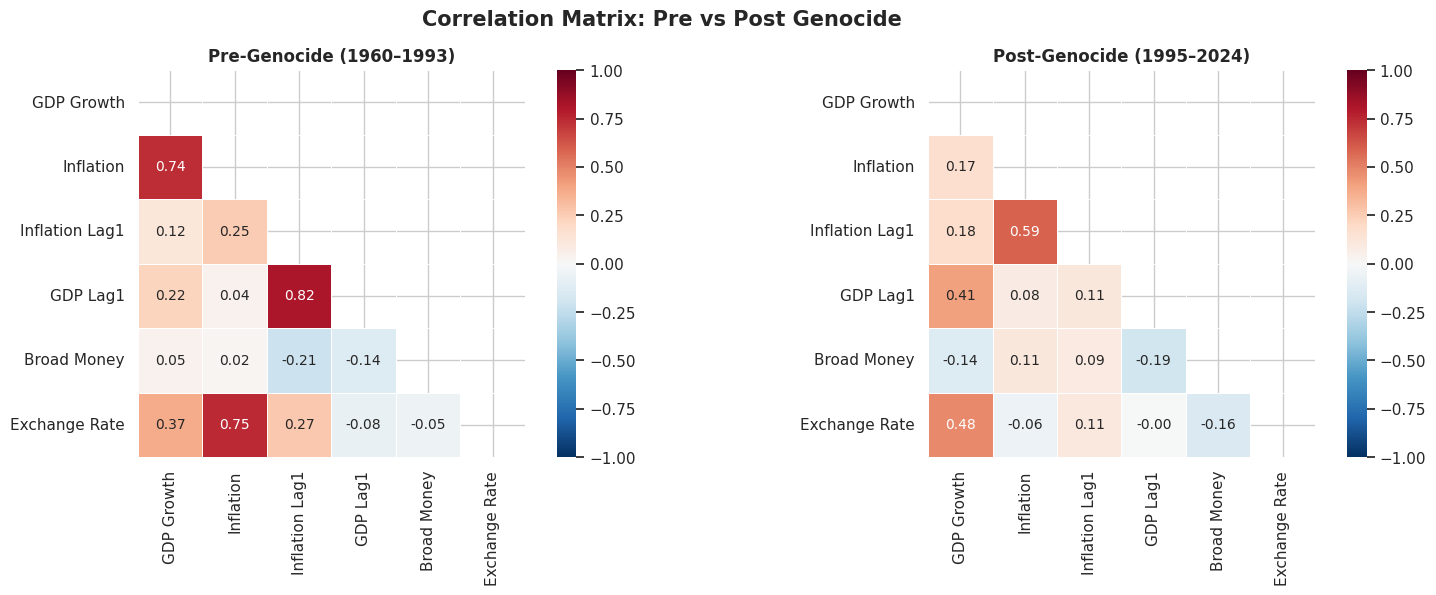

✓ Saved: correlation_matrix.png


In [148]:
corr_vars = [
    'Real_GDP_Growth_QoQ', 'Inflation_QoQ', 'inflation_lag1',
    'gdp_lag1', 'Broad_Money_Percent_GDP', 'D_Exchange_Rate'
]

var_labels = {
    'Real_GDP_Growth_QoQ'    : 'GDP Growth',
    'Inflation_QoQ'          : 'Inflation',
    'inflation_lag1'         : 'Inflation Lag1',
    'gdp_lag1'               : 'GDP Lag1',
    'Broad_Money_Percent_GDP': 'Broad Money',
    'D_Exchange_Rate'        : 'Exchange Rate'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Matrix: Pre vs Post Genocide', fontsize=15, fontweight='bold')

for ax, (data, label) in zip(axes, [
    (pre_df,  "Pre-Genocide (1960–1993)"),
    (post_df, "Post-Genocide (1995–2024)")
]):
    corr = data[corr_vars].corr()
    corr.index   = [var_labels[c] for c in corr_vars]
    corr.columns = [var_labels[c] for c in corr_vars]
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, square=True,
                linewidths=0.5, annot_kws={'fontsize':10})
    ax.set_title(label, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: correlation_matrix.png")

# **TIME SERIES: GDP GROWTH vs INFLATION**

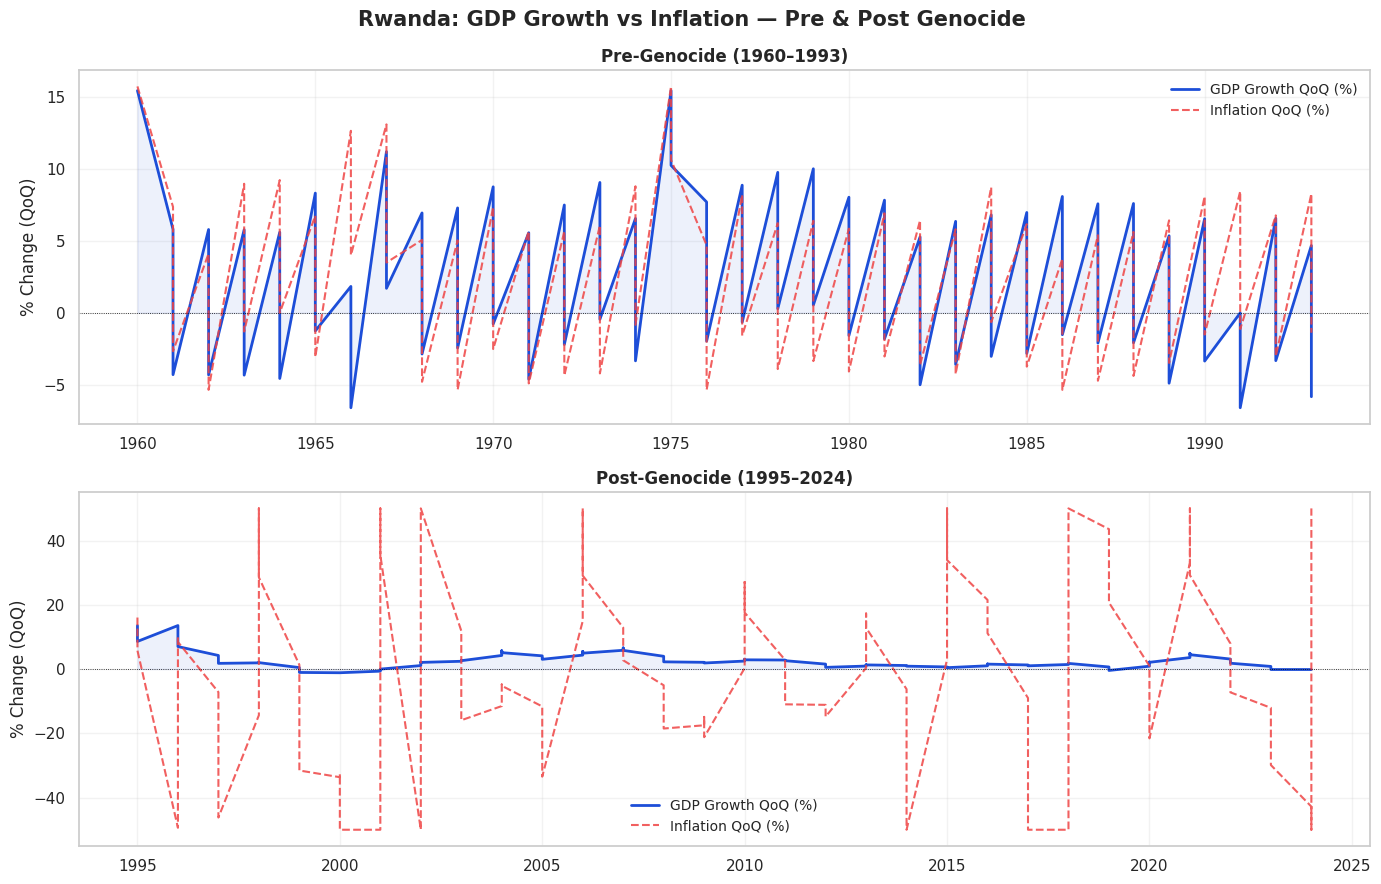

✓ Saved: gdp_inflation_trends.png


In [149]:

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("Rwanda: GDP Growth vs Inflation — Pre & Post Genocide", fontsize=15, fontweight='bold')

for ax, (data, label, c1, c2) in zip(axes, [
    (pre_df,  "Pre-Genocide (1960–1993)",  "#1d4ed8", "#ef4444"),
    (post_df, "Post-Genocide (1995–2024)", "#1d4ed8", "#ef4444")
]):
    ax.plot(data['Year'], data['Real_GDP_Growth_QoQ'], color=c1, linewidth=2, label='GDP Growth QoQ (%)')
    ax.plot(data['Year'], data['Inflation_QoQ'],       color=c2, linewidth=1.5, linestyle='--', alpha=0.85, label='Inflation QoQ (%)')
    ax.fill_between(data['Year'], data['Real_GDP_Growth_QoQ'], alpha=0.08, color=c1)
    ax.axhline(0, color='black', linewidth=0.6, linestyle=':')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel("% Change (QoQ)")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}gdp_inflation_trends.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: gdp_inflation_trends.png")

# **DISTRIBUTIONS: GDP GROWTH & INFLATION PER REGIME**

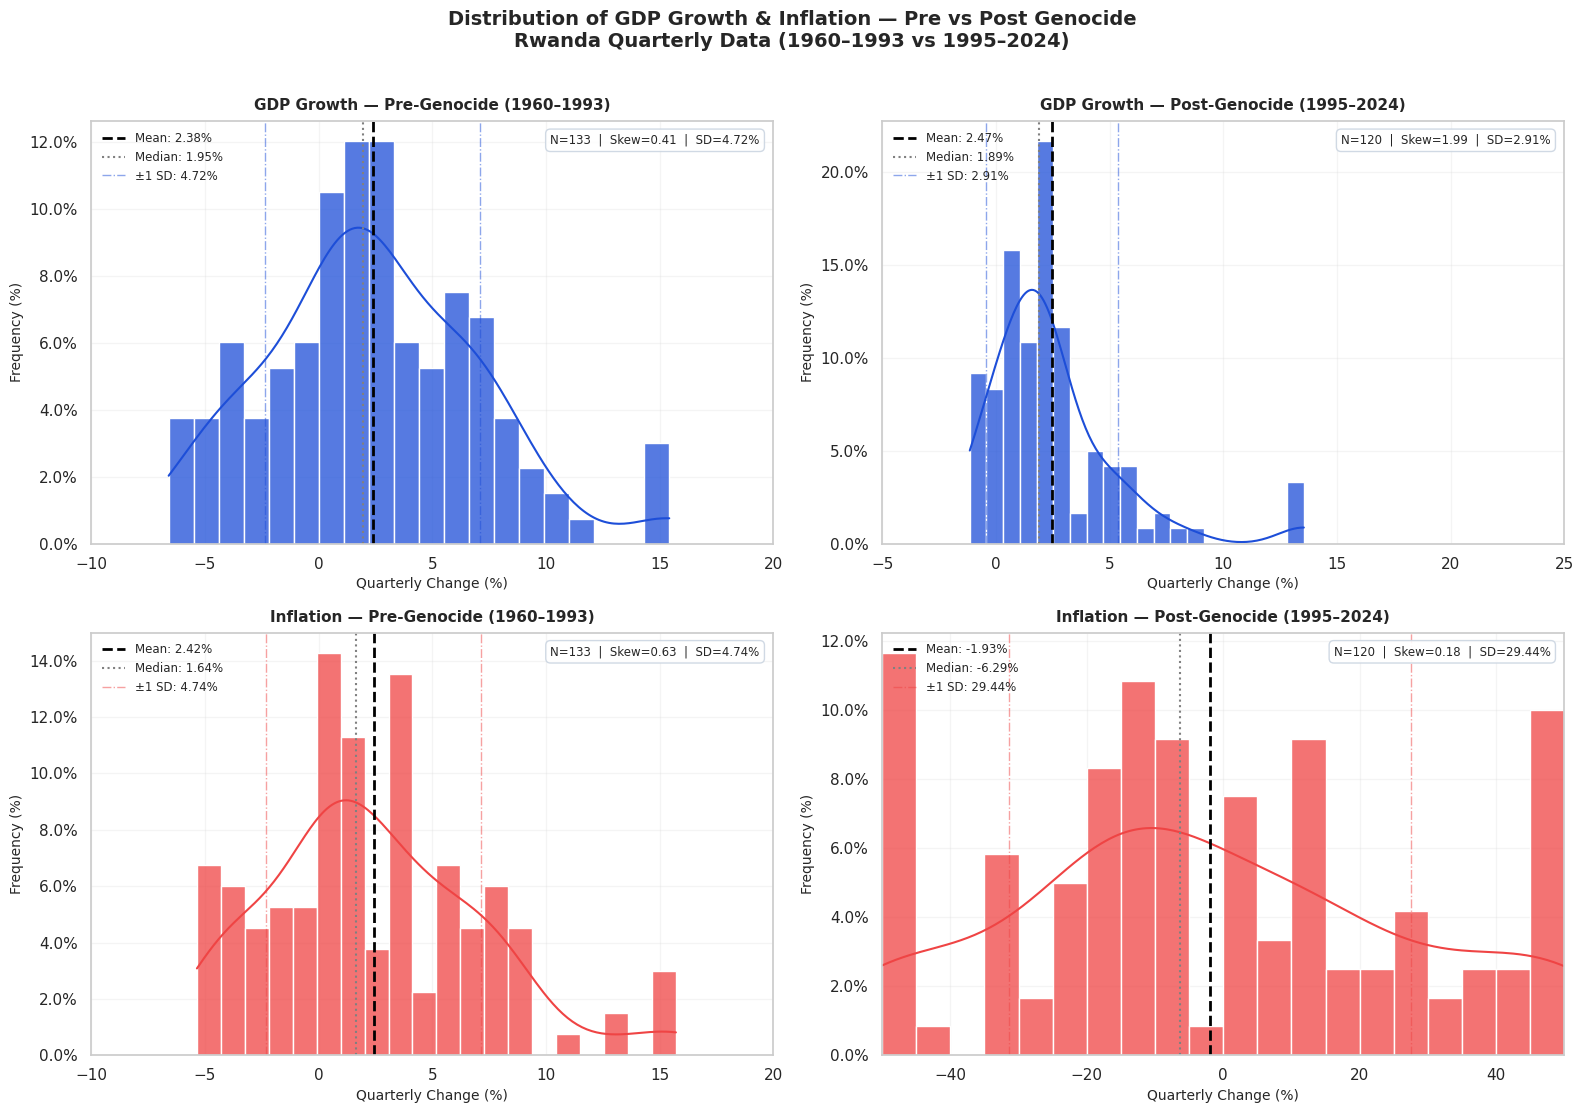

✓ Saved: distributions.png


In [150]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Distribution of GDP Growth & Inflation — Pre vs Post Genocide\nRwanda Quarterly Data (1960–1993 vs 1995–2024)",
             fontsize=14, fontweight='bold', y=1.01)

pairs = [
    (pre_df,  'Real_GDP_Growth_QoQ', "GDP Growth — Pre-Genocide (1960–1993)",  "#1d4ed8"),
    (post_df, 'Real_GDP_Growth_QoQ', "GDP Growth — Post-Genocide (1995–2024)", "#1d4ed8"),
    (pre_df,  'Inflation_QoQ',       "Inflation — Pre-Genocide (1960–1993)",   "#ef4444"),
    (post_df, 'Inflation_QoQ',       "Inflation — Post-Genocide (1995–2024)",  "#ef4444"),
]

x_limits = {
    ('pre',  'Real_GDP_Growth_QoQ') : (-10, 20),
    ('post', 'Real_GDP_Growth_QoQ') : (-5,  25),
    ('pre',  'Inflation_QoQ')       : (-10, 20),
    ('post', 'Inflation_QoQ')       : (-50, 50),
}

for ax, (data, var, title, color) in zip(axes.flat, pairs):
    regime = 'pre' if '1960' in title else 'post'
    series = data[var].dropna()

    mean_val   = series.mean()
    median_val = series.median()
    std_val    = series.std()
    skew_val   = series.skew()
    n          = len(series)

    # Plot with stat='percent' for thesis-ready Y axis
    sns.histplot(series, bins=20, kde=True, ax=ax,
                 color=color, edgecolor='white', alpha=0.75,
                 stat='percent')

    ax.axvline(mean_val,   color='black', linewidth=2,   linestyle='--',
               label=f"Mean: {mean_val:.2f}%")
    ax.axvline(median_val, color='gray',  linewidth=1.5, linestyle=':',
               label=f"Median: {median_val:.2f}%")
    ax.axvline(mean_val + std_val, color=color, linewidth=1, linestyle='-.',
               alpha=0.5, label=f"±1 SD: {std_val:.2f}%")
    ax.axvline(mean_val - std_val, color=color, linewidth=1, linestyle='-.',
               alpha=0.5)

    xlim = x_limits.get((regime, var))
    if xlim:
        ax.set_xlim(xlim)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel("Quarterly Change (%)", fontsize=10)
    ax.set_ylabel("Frequency (%)", fontsize=10)

    # Stats box inside plot
    stats_text = f"N={n}  |  Skew={skew_val:.2f}  |  SD={std_val:.2f}%"
    ax.text(0.98, 0.97, stats_text,
            transform=ax.transAxes,
            fontsize=8.5, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#cbd5e1', alpha=0.9))

    ax.legend(fontsize=8.5, loc='upper left')
    ax.grid(True, alpha=0.2)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: distributions.png")

# =========================================================
## **INFLATION vs GDP GROWTH (KEY RESEARCH PLOT)**

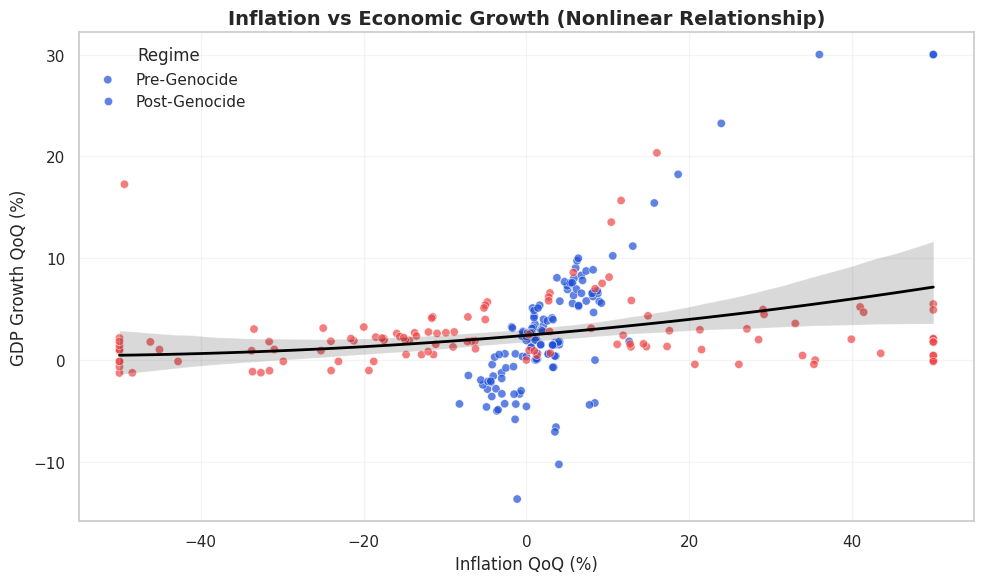

✓ Saved: inflation_vs_growth.png


In [151]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=full_df,
    x='Inflation_QoQ',
    y='Real_GDP_Growth_QoQ',
    hue=full_df['Year'] >= 1995,
    palette={False: '#1d4ed8', True: '#ef4444'},
    alpha=0.7
)

# Fit nonlinear trend
sns.regplot(
    data=full_df,
    x='Inflation_QoQ',
    y='Real_GDP_Growth_QoQ',
    scatter=False,
    order=2,
    color='black',
    line_kws={'linewidth': 2}
)

plt.title("Inflation vs Economic Growth (Nonlinear Relationship)", fontsize=14, fontweight='bold')
plt.xlabel("Inflation QoQ (%)")
plt.ylabel("GDP Growth QoQ (%)")
plt.legend(title="Regime", labels=['Pre-Genocide', 'Post-Genocide'])
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}inflation_vs_growth.png", dpi=150)
plt.show()

print("✓ Saved: inflation_vs_growth.png")

# **ECONOMIC TRENDS FROM 1964 TO 2024**

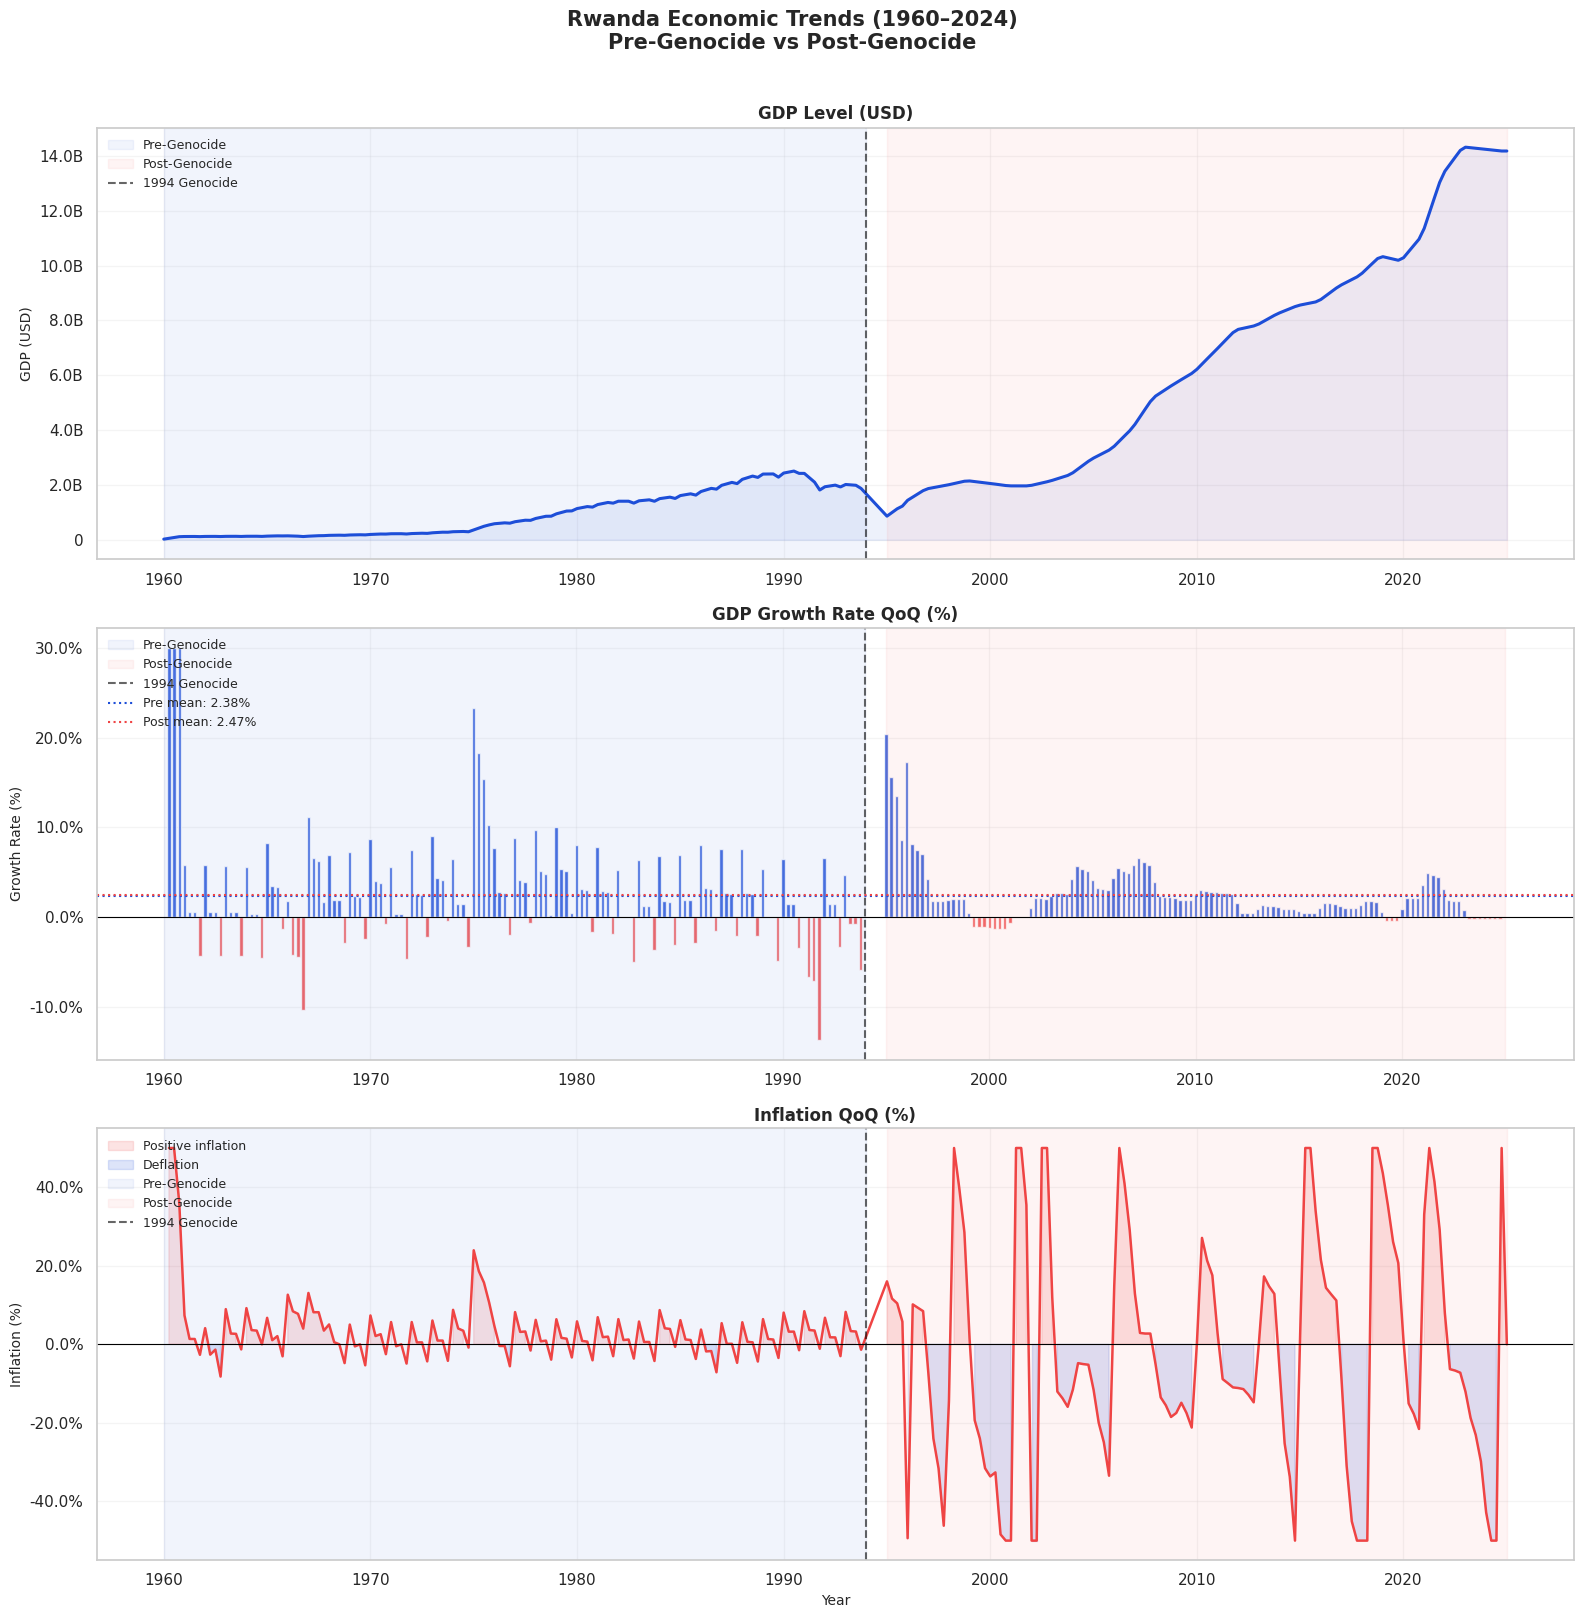

✓ Saved: economic_trends.png


In [152]:
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

def money_formatter(x, pos):
    if abs(x) >= 1e9: return f'{x/1e9:.1f}B'
    if abs(x) >= 1e6: return f'{x/1e6:.0f}M'
    if abs(x) >= 1e3: return f'{x/1e3:.0f}K'
    return f'{x:.0f}'

full_df = df[df['Year'] != 1994].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 16))
fig.suptitle("Rwanda Economic Trends (1960–2024)\nPre-Genocide vs Post-Genocide",
             fontsize=15, fontweight='bold', y=1.01)

def add_regime_shading(ax):
    ax.axvspan(pd.Timestamp('1960-01-01'), pd.Timestamp('1993-12-31'),
               alpha=0.06, color='#1d4ed8', label='Pre-Genocide')
    ax.axvspan(pd.Timestamp('1995-01-01'), pd.Timestamp('2024-12-31'),
               alpha=0.06, color='#ef4444', label='Post-Genocide')
    ax.axvline(pd.Timestamp('1994-01-01'), color='black',
               linewidth=1.5, linestyle='--', alpha=0.6, label='1994 Genocide')

# ── PLOT 1: GDP Level ─────────────────────────────────────────
ax = axes[0]
ax.plot(full_df['Date'], full_df['GDP_Current_USD'],
        color='#1d4ed8', linewidth=2.2)
ax.fill_between(full_df['Date'], full_df['GDP_Current_USD'],
                color='#1d4ed8', alpha=0.08)
add_regime_shading(ax)
ax.yaxis.set_major_formatter(FuncFormatter(money_formatter))
ax.set_title("GDP Level (USD)", fontsize=12, fontweight='bold')
ax.set_ylabel("GDP (USD)", fontsize=10)
ax.set_xlabel("")
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.2)

# ── PLOT 2: GDP Growth QoQ ────────────────────────────────────
ax = axes[1]
colors = full_df['Real_GDP_Growth_QoQ'].apply(lambda x: '#1d4ed8' if x >= 0 else '#ef4444')
ax.bar(full_df['Date'], full_df['Real_GDP_Growth_QoQ'],
       color=colors, width=60, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
add_regime_shading(ax)

pre_mean  = pre_df['Real_GDP_Growth_QoQ'].mean()
post_mean = post_df['Real_GDP_Growth_QoQ'].mean()
ax.axhline(pre_mean,  color='#1d4ed8', linewidth=1.5, linestyle=':',
           label=f'Pre mean: {pre_mean:.2f}%')
ax.axhline(post_mean, color='#ef4444', linewidth=1.5, linestyle=':',
           label=f'Post mean: {post_mean:.2f}%')

ax.set_title("GDP Growth Rate QoQ (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Growth Rate (%)", fontsize=10)
ax.set_xlabel("")
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.2)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}%'))

# ── PLOT 3: Inflation QoQ ─────────────────────────────────────
ax = axes[2]
ax.plot(full_df['Date'], full_df['Inflation_QoQ'],
        color='#ef4444', linewidth=1.8)
ax.fill_between(full_df['Date'], full_df['Inflation_QoQ'], 0,
                where=full_df['Inflation_QoQ'] >= 0,
                color='#ef4444', alpha=0.15, label='Positive inflation')
ax.fill_between(full_df['Date'], full_df['Inflation_QoQ'], 0,
                where=full_df['Inflation_QoQ'] < 0,
                color='#1d4ed8', alpha=0.15, label='Deflation')
ax.axhline(0, color='black', linewidth=0.8)
add_regime_shading(ax)

ax.set_title("Inflation QoQ (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Inflation (%)", fontsize=10)
ax.set_xlabel("Year", fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.2)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}economic_trends.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: economic_trends.png")

# **BARCHART TRENDIN**

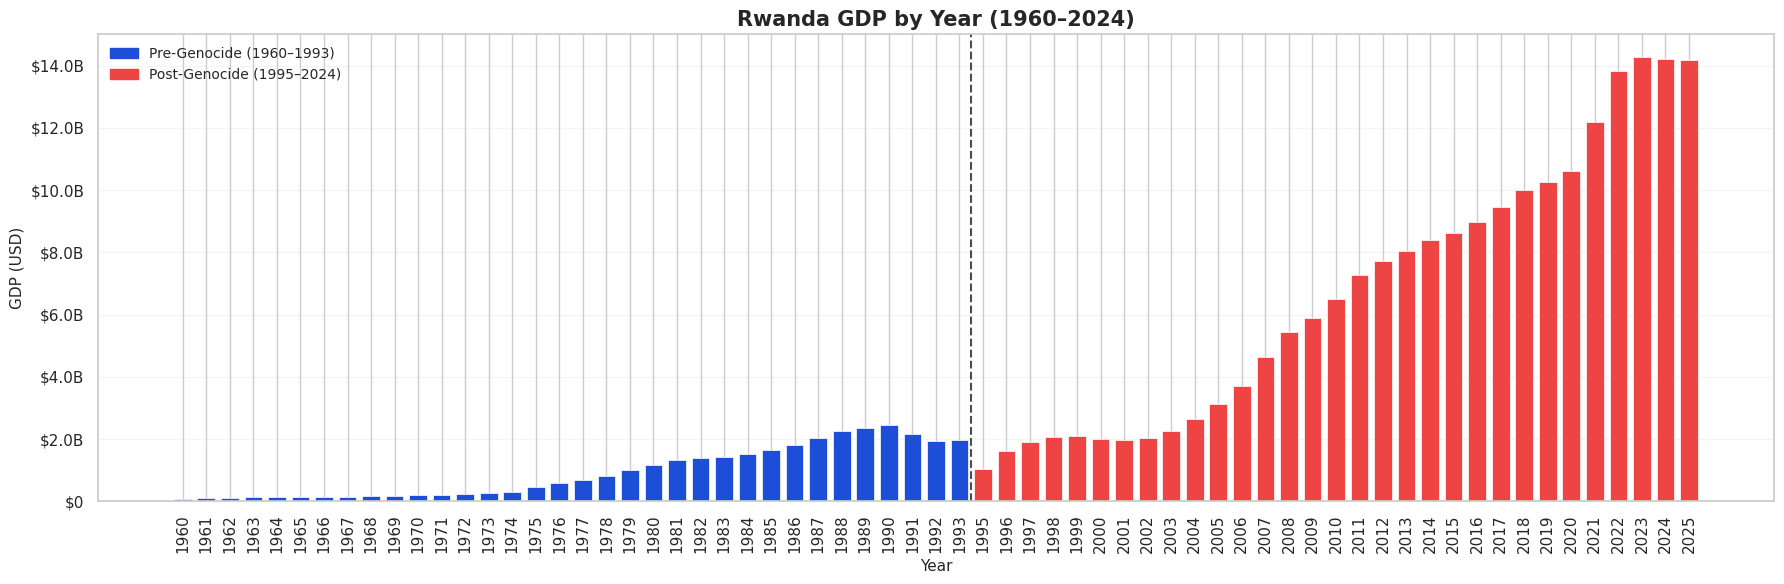

✓ Saved: gdp_bar_chart.png


In [153]:
# GDP BAR CHART BY YEAR
from matplotlib.ticker import FuncFormatter

def money_formatter(x, pos):
    if abs(x) >= 1e9: return f'${x/1e9:.1f}B'
    if abs(x) >= 1e6: return f'${x/1e6:.0f}M'
    return f'${x:.0f}'

# Aggregate to annual (mean per year, exclude 1994)
annual_df = df[df['Year'] != 1994].groupby('Year')['GDP_Current_USD'].mean().reset_index()

fig, ax = plt.subplots(figsize=(18, 6))

bar_colors = ['#1d4ed8' if y <= 1993 else '#ef4444' for y in annual_df['Year']]

bars = ax.bar(annual_df['Year'].astype(str), annual_df['GDP_Current_USD'],
              color=bar_colors, edgecolor='white', linewidth=0.5, width=0.75)

ax.axvline(x=annual_df[annual_df['Year'] == 1993].index[0] + 0.5,
           color='black', linewidth=1.5, linestyle='--', alpha=0.7, label='1994 excluded')

ax.set_title("Rwanda GDP by Year (1960–2024)", fontsize=15, fontweight='bold')
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("GDP (USD)", fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(money_formatter))
ax.tick_params(axis='x', rotation=90)
ax.grid(axis='y', alpha=0.2)

pre_patch  = mpatches.Patch(color='#1d4ed8', label='Pre-Genocide (1960–1993)')
post_patch = mpatches.Patch(color='#ef4444', label='Post-Genocide (1995–2024)')
ax.legend(handles=[pre_patch, post_patch], fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}gdp_bar_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: gdp_bar_chart.png")

In [154]:
# CELL 13 — REBUILD FEATURES (if running standalone)
from scipy.stats.mstats import winsorize

df['Inflation_QoQ']       = df['GDP_Deflator'].pct_change() * 100
df['Real_GDP_Growth_QoQ'] = df['GDP_Current_USD'].pct_change() * 100
df['D_Exchange_Rate']     = df['Official_Exchange_Rate_LCU_per_USD'].pct_change() * 100
df['Log_GDP']             = np.log(df['GDP_Current_USD'])
df['inflation_squared']   = df['Inflation_QoQ'] ** 2
df['post_genocide']       = (df['Year'] >= 1995).astype(int)

df['Inflation_QoQ']       = df['Inflation_QoQ'].clip(-50, 50)
df['Real_GDP_Growth_QoQ'] = df['Real_GDP_Growth_QoQ'].clip(-30, 30)
df['D_Exchange_Rate']     = df['D_Exchange_Rate'].clip(-50, 50)

for lag in [1, 2, 3, 4]:
    df[f'inflation_lag{lag}'] = df['Inflation_QoQ'].shift(lag)
    df[f'gdp_lag{lag}']       = df['Real_GDP_Growth_QoQ'].shift(lag)

PRE_FEATURES = [
    'Inflation_QoQ', 'inflation_lag1', 'inflation_lag2',
    'gdp_lag1', 'gdp_lag2', 'Broad_Money_Percent_GDP',
    'D_Exchange_Rate', 'inflation_squared'
]

POST_FEATURES = PRE_FEATURES + [
    'Foreign_Direct_Investment_Net_Inflows_Percent_GDP',
    'Lending_Interest_Rate_Percent',
    'Unemployment_Total_Percent_Labor_Force'
]

TARGET = 'Real_GDP_Growth_QoQ'

pre_df  = df[(df['Year'] >= 1960) & (df['Year'] <= 1993)].dropna(subset=PRE_FEATURES  + [TARGET]).copy()
post_df = df[(df['Year'] >= 1995) & (df['Year'] <= 2024)].dropna(subset=POST_FEATURES + [TARGET]).copy()

for col in ['Inflation_QoQ', 'Real_GDP_Growth_QoQ']:
    pre_df[col]  = winsorize(pre_df[col],  limits=[0.025, 0.025])
    post_df[col] = winsorize(post_df[col], limits=[0.025, 0.025])

print(f"Pre  samples : {len(pre_df)}")
print(f"Post samples : {len(post_df)}")

Pre  samples : 133
Post samples : 120


# **STATIONARITY TESTING - AUGMENTED DICKEY-FULLER TEST**

In [155]:
from statsmodels.tsa.stattools import adfuller, kpss
from IPython.display import display, HTML

def adf_test(series, name):
    y = series.dropna()
    if len(y) < 10: return None
    adf_stat, p_val, used_lag, n_obs, crit_vals, _ = adfuller(y, autolag='AIC')
    return {
        'Variable'         : name,
        'N'                : int(n_obs),
        'ADF Statistic'    : round(adf_stat, 4),
        'p-value'          : round(p_val, 4),
        'Lags Used'        : int(used_lag),
        '1% CV'            : round(crit_vals['1%'], 4),
        '5% CV'            : round(crit_vals['5%'], 4),
        'ADF Decision'     : 'Stationary I(0)' if p_val < 0.05 else 'Non-Stationary I(1)',
    }

def kpss_test(series, name):
    y = series.dropna()
    if len(y) < 10: return None
    kpss_stat, p_val, lags, crit_vals = kpss(y, regression='c', nlags='auto')
    return {
        'Variable'         : name,
        'KPSS Statistic'   : round(kpss_stat, 4),
        'p-value'          : round(p_val, 4),
        '5% CV'            : round(crit_vals['5%'], 4),
        'KPSS Decision'    : 'Non-Stationary I(1)' if p_val < 0.05 else 'Stationary I(0)',
    }

def style_table(df_table, title):
    return (
        df_table.style
        .set_caption(title)
        .set_table_styles([
            {'selector': 'caption',    'props': [('caption-side','top'),('font-size','15px'),('font-weight','bold'),('color','#0f172a'),('padding','8px')]},
            {'selector': 'th',         'props': [('background-color','#0f172a'),('color','white'),('font-weight','bold'),('text-align','center'),('border','1px solid #d1d5db')]},
            {'selector': 'td',         'props': [('border','1px solid #d1d5db'),('padding','8px'),('color','#111827'),('background-color','white')]},
            {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color','#f8fafc')]},
            {'selector': 'tbody tr:hover',           'props': [('background-color','#e0f2fe')]},
            {'selector': 'tbody th',   'props': [('background-color','#334155'),('color','white'),('font-weight','bold')]},
        ])
        .format(precision=4, na_rep='—')
        .set_properties(**{'text-align':'center','font-size':'13px'})
    )

test_vars = [
    'Real_GDP_Growth_QoQ', 'Inflation_QoQ',
    'D_Exchange_Rate', 'Broad_Money_Percent_GDP',
    'inflation_lag1', 'gdp_lag1'
]

var_labels = {
    'Real_GDP_Growth_QoQ'    : 'GDP Growth QoQ (%)',
    'Inflation_QoQ'          : 'Inflation QoQ (%)',
    'D_Exchange_Rate'        : 'Exchange Rate Change (%)',
    'Broad_Money_Percent_GDP': 'Broad Money (% GDP)',
    'inflation_lag1'         : 'Inflation Lag 1',
    'gdp_lag1'               : 'GDP Growth Lag 1'
}

display(HTML("""
<div style="background:linear-gradient(90deg,#0f172a,#1d4ed8);padding:16px 20px;
border-radius:12px;color:white;font-family:Arial,sans-serif;margin-bottom:14px;">
    <h2 style="margin:0;font-size:22px;">Stationarity Testing — ADF & KPSS</h2>
    <p style="margin:6px 0 0;font-size:13px;opacity:.9;">
        Tested per regime | ADF H0: unit root exists | KPSS H0: series is stationary
    </p>
</div>"""))

for regime_df, label in [(pre_df, "PRE-GENOCIDE (1960–1993)"),
                          (post_df, "POST-GENOCIDE (1995–2024)")]:

    adf_results  = [adf_test(regime_df[v],  var_labels[v]) for v in test_vars if v in regime_df.columns]
    kpss_results = [kpss_test(regime_df[v], var_labels[v]) for v in test_vars if v in regime_df.columns]

    adf_df  = pd.DataFrame([r for r in adf_results  if r]).set_index('Variable')
    kpss_df = pd.DataFrame([r for r in kpss_results if r]).set_index('Variable')

    combined = adf_df.join(kpss_df[['KPSS Statistic','p-value','KPSS Decision']],
                           rsuffix='_kpss')

    # Confirm stationarity: stationary only if BOTH tests agree
    combined['Final Verdict'] = combined.apply(
        lambda r: '✓ Stationary' if r['ADF Decision'] == 'Stationary I(0)'
                  and r['KPSS Decision'] == 'Stationary I(0)'
                  else '✗ Non-Stationary', axis=1
    )

    display(HTML(f'<h3 style="margin:16px 0 6px;color:#0f172a;">TABLE: {label}</h3>'))
    display(style_table(combined.reset_index(), f"ADF + KPSS Stationarity Results — {label}"))

    stationary     = combined[combined['Final Verdict'] == '✓ Stationary'].index.tolist()
    non_stationary = combined[combined['Final Verdict'] == '✗ Non-Stationary'].index.tolist()

    print(f"\n{label}")
    print(f"  Stationary     : {', '.join(stationary) if stationary else 'None'}")
    print(f"  Non-Stationary : {', '.join(non_stationary) if non_stationary else 'None'}")

,Variable,N,ADF Statistic,p-value,Lags Used,1% CV,5% CV,ADF Decision,KPSS Statistic,p-value_kpss,KPSS Decision,Final Verdict
0,GDP Growth QoQ (%),119,-1.7089,0.4265,13,-3.4865,-2.8862,Non-Stationary I(1),0.3754,0.0878,Stationary I(0),✗ Non-Stationary
1,Inflation QoQ (%),120,-3.2084,0.0195,12,-3.4861,-2.8859,Stationary I(0),0.2183,0.1000,Stationary I(0),✓ Stationary
2,Exchange Rate Change (%),120,-2.5706,0.0992,12,-3.4861,-2.8859,Non-Stationary I(1),0.2257,0.1000,Stationary I(0),✗ Non-Stationary
3,Broad Money (% GDP),119,-4.6745,0.0001,13,-3.4865,-2.8862,Stationary I(0),0.8026,0.0100,Non-Stationary I(1),✗ Non-Stationary
4,Inflation Lag 1,120,-3.0817,0.0279,12,-3.4861,-2.8859,Stationary I(0),0.3505,0.0985,Stationary I(0),✓ Stationary
5,GDP Growth Lag 1,120,-1.9946,0.2889,12,-3.4861,-2.8859,Non-Stationary I(1),0.3371,0.1000,Stationary I(0),✗ Non-Stationary



PRE-GENOCIDE (1960–1993)
  Stationary     : Inflation QoQ (%), Inflation Lag 1
  Non-Stationary : GDP Growth QoQ (%), Exchange Rate Change (%), Broad Money (% GDP), GDP Growth Lag 1


,Variable,N,ADF Statistic,p-value,Lags Used,1% CV,5% CV,ADF Decision,KPSS Statistic,p-value_kpss,KPSS Decision,Final Verdict
0,GDP Growth QoQ (%),114,-2.8372,0.0532,5,-3.4891,-2.8872,Non-Stationary I(1),0.3945,0.0795,Stationary I(0),✗ Non-Stationary
1,Inflation QoQ (%),118,-7.2421,0.0000,1,-3.4870,-2.8864,Stationary I(0),0.0495,0.1000,Stationary I(0),✓ Stationary
2,Exchange Rate Change (%),107,-2.2054,0.2043,12,-3.4930,-2.8890,Non-Stationary I(1),0.4977,0.0422,Non-Stationary I(1),✗ Non-Stationary
3,Broad Money (% GDP),111,-2.2484,0.1891,8,-3.4907,-2.8880,Non-Stationary I(1),1.4732,0.0100,Non-Stationary I(1),✗ Non-Stationary
4,Inflation Lag 1,118,-6.9238,0.0000,1,-3.4870,-2.8864,Stationary I(0),0.0451,0.1000,Stationary I(0),✓ Stationary
5,GDP Growth Lag 1,114,-3.4674,0.0089,5,-3.4891,-2.8872,Stationary I(0),0.2717,0.1000,Stationary I(0),✓ Stationary



POST-GENOCIDE (1995–2024)
  Stationary     : Inflation QoQ (%), Inflation Lag 1, GDP Growth Lag 1
  Non-Stationary : GDP Growth QoQ (%), Exchange Rate Change (%), Broad Money (% GDP)


"ADF and KPSS tests confirm that inflation and its lags are stationary I(0) in both regimes. GDP growth, exchange rate changes, and broad money exhibit non-stationarity, requiring first differencing before inclusion in regression models. This mixed integration order justifies the use of machine learning models which do not assume stationarity, alongside differenced variables for classical comparisons.

# **TRANSFORMATION: FIRST DIFFERENCE NON-STATIONARY VARIABLES**

"First differencing was applied to exchange rate changes and broad money supply to achieve stationarity, confirmed by ADF and KPSS tests. GDP growth and inflation were already expressed as period-on-period rates, rendering them stationary without further transformation."

ALSO, ML models do not require stationarity the way OLS does. But by differencing we removed spurious trends, making patterns cleaner and more learnable for all models.

In [156]:
for col in ['D_Exchange_Rate', 'Broad_Money_Percent_GDP']:
    pre_df[f'd_{col}']  = pre_df[col].diff()
    post_df[f'd_{col}'] = post_df[col].diff()

# Update feature sets to use differenced versions
PRE_FEATURES_FINAL = [
    'Inflation_QoQ', 'inflation_lag1', 'inflation_lag2',
    'gdp_lag1', 'gdp_lag2',
    'd_Broad_Money_Percent_GDP', 'd_D_Exchange_Rate',
    'inflation_squared'
]

POST_FEATURES_FINAL = PRE_FEATURES_FINAL + [
    'Foreign_Direct_Investment_Net_Inflows_Percent_GDP',
    'Lending_Interest_Rate_Percent',
    'Unemployment_Total_Percent_Labor_Force'
]

# Re-dropna after differencing
pre_df  = pre_df.dropna(subset=PRE_FEATURES_FINAL  + [TARGET]).copy()
post_df = post_df.dropna(subset=POST_FEATURES_FINAL + [TARGET]).copy()

print(f"Pre  samples after differencing : {len(pre_df)}")
print(f"Post samples after differencing : {len(post_df)}")

Pre  samples after differencing : 132
Post samples after differencing : 119


# **VARIABLES READY FOR ML MOIDELS**

PRE-GENOCIDE MODEL (132 samples)

1. Inflation_QoQ
2. inflation_lag1
3. inflation_lag2
4. gdp_lag1
5. gdp_lag2
6. d_Broad_Money_Percent_GDP
7. d_D_Exchange_Rate
8. inflation_squared

TARGET: Real_GDP_Growth_QoQ

POST-GENOCIDE MODEL (119 samples)

1. Inflation_QoQ
2. inflation_lag1
3. inflation_lag2
4. gdp_lag1
5. gdp_lag2
6. d_Broad_Money_Percent_GDP
7. d_D_Exchange_Rate
8. inflation_squared
9. Foreign_Direct_Investment_Net_Inflows_Percent_GDP
10. Lending_Interest_Rate_Percent
11. Unemployment_Total_Percent_Labor_Force

TARGET: Real_GDP_Growth_QoQ

1. The Target Variable (What we are predicting)
Real_GDP_Growth_QoQ: This is the Quarter-on-Quarter percentage change in Real Gross Domestic Product. It represents the speed of Rwanda's economic growth. Using "Real" GDP means we have stripped out the effects of inflation to see the actual increase in the country's production and services.

2. Core Predictors (Used in both models)
Inflation_QoQ: The quarterly inflation rate (based on the GDP Deflator). It measures how much prices increased compared to the previous three months.

A. Inflation_lag1 & Inflation_lag2: These are the inflation rates from one quarter ago and two quarters ago. We include these because price changes often take 3 to 6 months to actually impact consumer spending and business growth.

B. GDP_lag1 & GDP_lag2: These are the GDP growth rates from the previous two quarters. This represents economic momentum. If the economy grew strongly in the last six months, it is likely to continue that trend (Path Dependency).

C. d_Broad_Money_Percent_GDP: The "d_" stands for First Difference. This is the change in the total money supply circulating in the economy relative to the size of the economy. It measures "Monetary Expansion"—basically, is the central bank putting more or less money into the system?

D. d_D_Exchange_Rate: This is the change in the percentage change of the Exchange Rate (LCU per USD). It captures the volatility of the Rwandan Franc. If this number is high, the currency is devaluing quickly, which makes imports more expensive.

E. Inflation_squared: This is the inflation rate multiplied by itself. We use this to test for non-linear effects. It helps the model see if "high inflation" hurts the economy much more severely than "low inflation" does.

3. Modern Era Predictors (Post-Genocide only)
These variables represent the modernization of Rwanda's economy after 1995: **bold text**

A. Foreign_Direct_Investment_Net_Inflows_Percent_GDP (FDI): This measures the amount of money foreign companies and investors are putting into Rwanda (like building factories or investing in local companies). It is a key indicator of international confidence in Rwanda's stability.

B. Lending_Interest_Rate_Percent: This is the average interest rate charged by banks to private sector borrowers. It represents the cost of borrowing. When this is high, businesses find it harder to take loans to expand, which usually slows down GDP growth.

C. Unemployment_Total_Percent_Labor_Force: The percentage of the active workforce that is without work but available for it. This is a measure of economic health and labor utilization. In the modern era, tracking unemployment is vital for understanding if "growth" is actually creating "jobs.

# **MACHINE LEARNING MODELS**

# ***`1. OLS REGRESSION MODEL`***

# **PRE AND PSOT GENOCIDE ORL REGRESSTION**

,Variable,Coefficient,Std Error,t-stat,p-value,CI Lower,CI Upper,Sig
0,const,0.0335,0.2262,0.1481,0.8823,-0.4099,0.4769,
1,Inflation_QoQ,1.0323,0.2231,4.6261,0.0000,0.5949,1.4696,***
2,inflation_lag1,-0.8761,0.2229,-3.9311,0.0001,-1.3128,-0.4393,***
3,inflation_lag2,0.0841,0.0684,1.2295,0.2189,-0.0499,0.2180,
4,gdp_lag1,0.7394,0.1163,6.3579,0.0000,0.5115,0.9673,***
5,gdp_lag2,-0.0549,0.0738,-0.7438,0.4570,-0.1995,0.0897,
6,d_Broad_Money_Percent_GDP,0.3701,0.3143,1.1777,0.2389,-0.2458,0.9861,
7,d_D_Exchange_Rate,-0.1937,0.2021,-0.9583,0.3379,-0.5898,0.2024,
8,inflation_squared,0.0032,0.0036,0.8805,0.3786,-0.0039,0.0103,


,Metric,Value
0,R²,0.7911
1,Adj R²,0.7775
2,RMSE,2.0925
3,MAE,1.3624
4,Durbin-Watson,1.6420
5,JB p-value,0.0000
6,N,132.0000


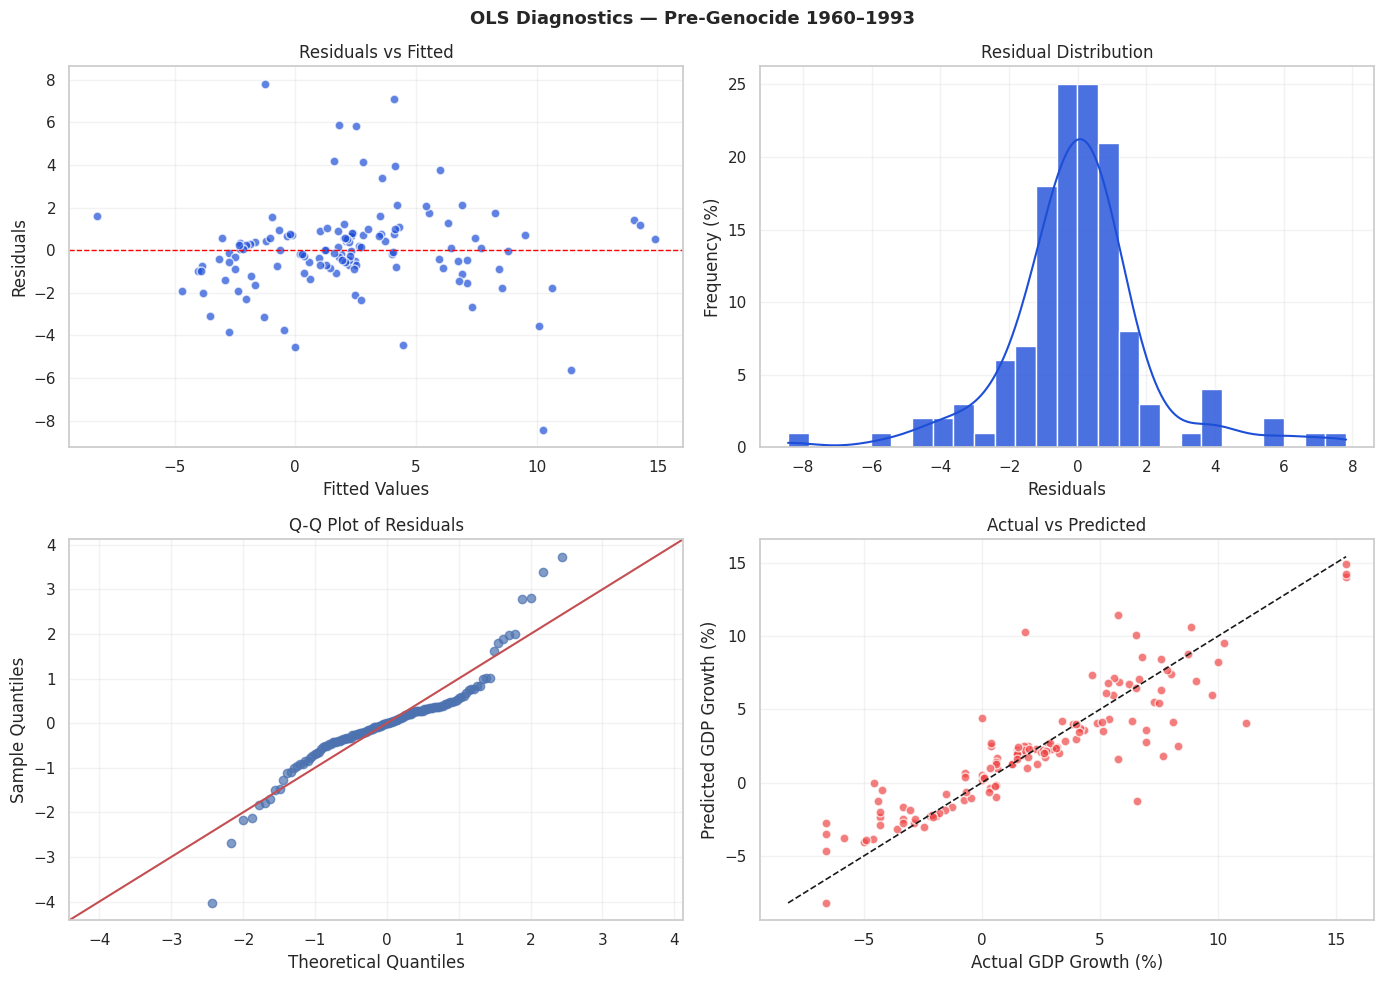

,Variable,Coefficient,Std Error,t-stat,p-value,CI Lower,CI Upper,Sig
0,const,-0.7511,2.4632,-0.3049,0.7604,-5.5789,4.0768,
1,Inflation_QoQ,0.0039,0.0033,1.2027,0.2291,-0.0025,0.0104,
2,inflation_lag1,-0.0024,0.0041,-0.6011,0.5478,-0.0104,0.0055,
3,inflation_lag2,0.0002,0.0038,0.0499,0.9602,-0.0073,0.0077,
4,gdp_lag1,0.7738,0.0299,25.9073,0.0000,0.7152,0.8323,***
5,gdp_lag2,0.0500,0.0181,2.7580,0.0058,0.0145,0.0856,***
6,d_Broad_Money_Percent_GDP,-0.0481,0.2404,-0.2002,0.8413,-0.5193,0.4231,
7,d_D_Exchange_Rate,0.0985,0.0234,4.2181,0.0000,0.0528,0.1443,***
8,inflation_squared,0.0000,0.0000,1.5692,0.1166,-0.0000,0.0000,
9,Foreign_Direct_Investment_Net_Inflows_Percent_GDP,-0.0287,0.0859,-0.3337,0.7386,-0.1970,0.1397,


,Metric,Value
0,R²,0.9065
1,Adj R²,0.8969
2,RMSE,0.8343
3,MAE,0.5906
4,Durbin-Watson,1.5463
5,JB p-value,0.0000
6,N,119.0000


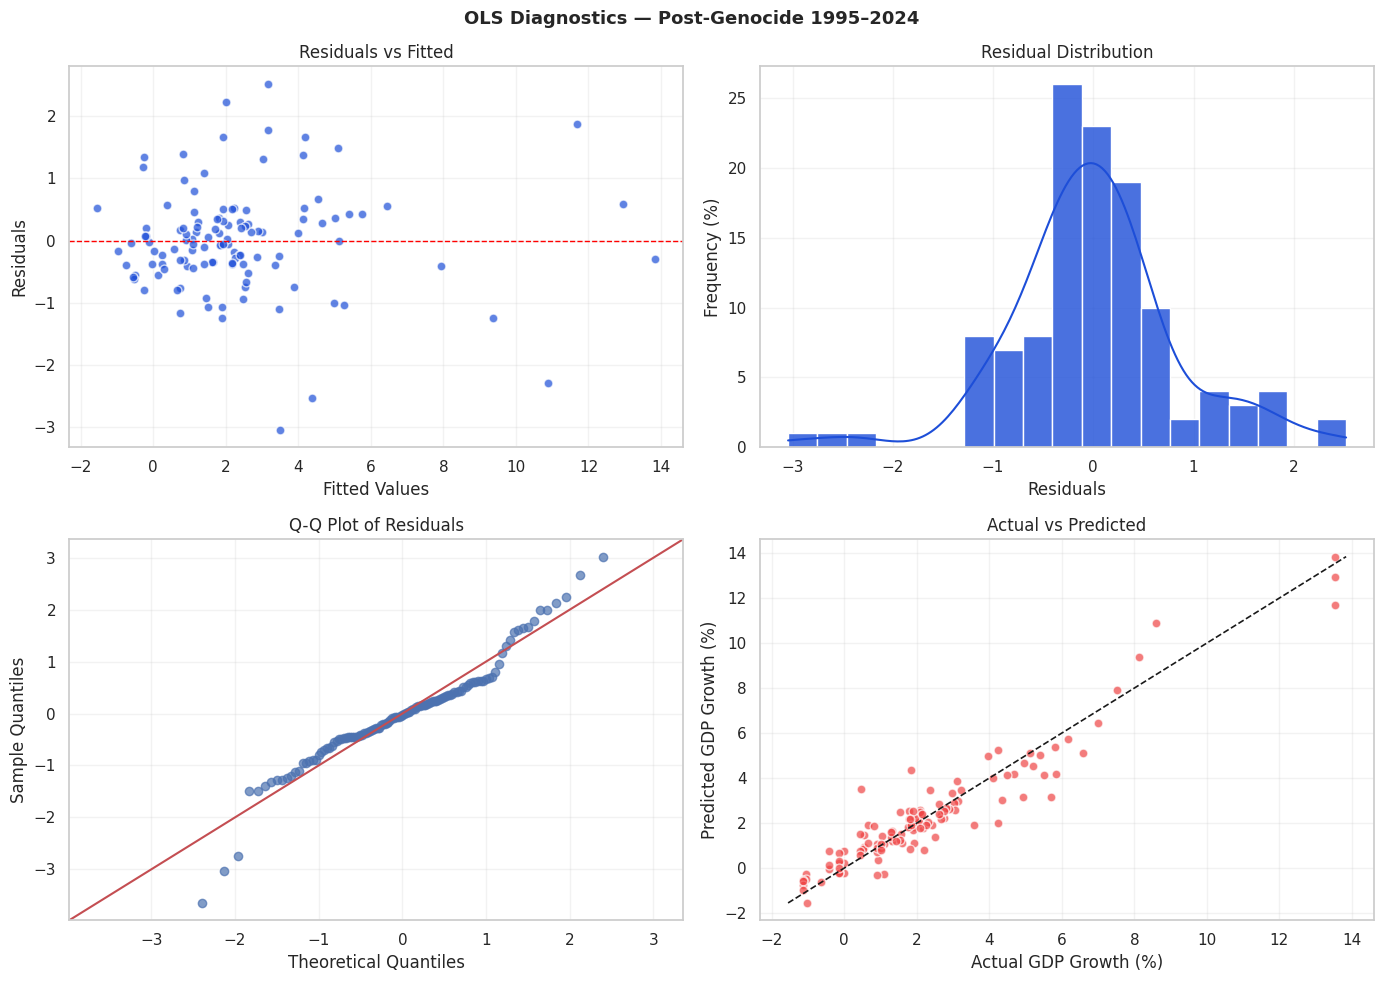

In [157]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from IPython.display import display, HTML

def run_ols(data, features, target, label):

    X = sm.add_constant(data[features])
    y = data[target]
    model = sm.OLS(y, X).fit(cov_type='HC1')

    y_pred    = model.predict(X)
    residuals = y - y_pred
    dw        = durbin_watson(residuals)
    jb_stat, jb_p, skew, kurt = jarque_bera(residuals)

    display(HTML(f"""
    <div style="background:linear-gradient(90deg,#0f172a,#1d4ed8);padding:14px 20px;
    border-radius:12px;color:white;font-family:Arial,sans-serif;margin:16px 0 10px;">
        <h3 style="margin:0;font-size:18px;">OLS Regression — {label}</h3>
        <p style="margin:4px 0 0;font-size:12px;opacity:.9;">
            Robust HC1 standard errors | N={len(y)} | Features={len(features)}
        </p>
    </div>"""))

    # Coefficient table
    coef_df = pd.DataFrame({
        'Variable'   : model.params.index,
        'Coefficient': model.params.values.round(4),
        'Std Error'  : model.bse.values.round(4),
        't-stat'     : model.tvalues.values.round(4),
        'p-value'    : model.pvalues.values.round(4),
        'CI Lower'   : model.conf_int()[0].values.round(4),
        'CI Upper'   : model.conf_int()[1].values.round(4),
        'Sig'        : ['***' if p < 0.01 else '**' if p < 0.05
                        else '*' if p < 0.10 else '' for p in model.pvalues]
    })
    display(style_table(coef_df, f"Coefficient Table — {label}"))

    # Fit statistics
    fit_df = pd.DataFrame({
        'Metric': ['R²', 'Adj R²', 'RMSE', 'MAE', 'Durbin-Watson', 'JB p-value', 'N'],
        'Value' : [
            round(model.rsquared, 4),
            round(model.rsquared_adj, 4),
            round(np.sqrt(np.mean(residuals**2)), 4),
            round(np.mean(np.abs(residuals)), 4),
            round(dw, 4),
            round(jb_p, 4),
            len(y)
        ]
    })
    display(style_table(fit_df, f"Fit Statistics — {label}"))

    # Diagnostic plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"OLS Diagnostics — {label}", fontsize=13, fontweight='bold')

    axes[0,0].scatter(y_pred, residuals, color='#1d4ed8', alpha=0.7, edgecolor='white', s=40)
    axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0,0].set_title('Residuals vs Fitted')
    axes[0,0].set_xlabel('Fitted Values')
    axes[0,0].set_ylabel('Residuals')
    axes[0,0].grid(True, alpha=0.25)

    sns.histplot(residuals, kde=True, ax=axes[0,1], color='#1d4ed8', edgecolor='white', alpha=0.8)
    axes[0,1].set_title('Residual Distribution')
    axes[0,1].set_xlabel('Residuals')
    axes[0,1].set_ylabel('Frequency (%)')
    axes[0,1].grid(True, alpha=0.25)

    sm.qqplot(residuals, line='45', fit=True, ax=axes[1,0], alpha=0.7)
    axes[1,0].set_title('Q-Q Plot of Residuals')
    axes[1,0].grid(True, alpha=0.25)

    axes[1,1].scatter(y, y_pred, color='#ef4444', alpha=0.7, edgecolor='white', s=40)
    mn, mx = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
    axes[1,1].plot([mn, mx], [mn, mx], 'k--', linewidth=1.2)
    axes[1,1].set_title('Actual vs Predicted')
    axes[1,1].set_xlabel('Actual GDP Growth (%)')
    axes[1,1].set_ylabel('Predicted GDP Growth (%)')
    axes[1,1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}ols_diagnostics_{label.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    return model, fit_df

# Run OLS on both regimes
model_pre,  fit_pre  = run_ols(pre_df,  PRE_FEATURES_FINAL,  TARGET, "Pre-Genocide 1960–1993")
model_post, fit_post = run_ols(post_df, POST_FEATURES_FINAL, TARGET, "Post-Genocide 1995–2024")

# **VIF CHECK FOR MULTICOLLINEARITY CHECK VOR PREDICTORS**

In [158]:
def check_vif(data, features):
    X_vif = sm.add_constant(data[features])
    vif_table = pd.DataFrame()
    vif_table['Variable'] = X_vif.columns
    vif_table['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    return vif_table[vif_table['Variable'] != 'const']

# Check for Pre-Genocide
print("Pre-Genocide VIF:")
print(check_vif(pre_df, PRE_FEATURES_FINAL))

# Check for Post-Genocide
print("\nPost-Genocide VIF:")
print(check_vif(post_df, POST_FEATURES_FINAL))

Pre-Genocide VIF:
                    Variable        VIF
1              Inflation_QoQ   6.882983
2             inflation_lag1  12.571589
3             inflation_lag2   7.669150
4                   gdp_lag1   5.802864
5                   gdp_lag2   7.137677
6  d_Broad_Money_Percent_GDP   1.306223
7          d_D_Exchange_Rate   8.434538
8          inflation_squared   2.048782

Post-Genocide VIF:
                                             Variable       VIF
1                                       Inflation_QoQ  2.037277
2                                      inflation_lag1  3.341765
3                                      inflation_lag2  2.184995
4                                            gdp_lag1  1.892768
5                                            gdp_lag2  1.175428
6                           d_Broad_Money_Percent_GDP  1.310224
7                                   d_D_Exchange_Rate  1.389972
8                                   inflation_squared  1.082960
9   Foreign_Direct_Investm

# **1. MANY MODELS FOR FOR LOOP LOOK USING HIGH TUNINGS**

In [159]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# We will run this function for Pre-Genocide and Post-Genocide separately
def run_ml_comparison(data, features, target, label):
    X = data[features]
    y = data[target]

    # 1. Time-Series Split (Last 20% for testing)
    split_idx = int(len(data) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # 2. Scaling (Crucial for Ridge/Lasso/ElasticNet)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.1),
        "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
    }

    results = []

    for name, model in models.items():
        # Use scaled data for linear models, raw data is fine for trees but scaled works for both
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

        results.append({
            "Model": name,
            "R2 Score": r2_score(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "MAE": mean_absolute_error(y_test, preds)
        })

    leaderboard = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
    return leaderboard

# EXECUTION
# Pre-Genocide
pre_leaderboard = run_ml_comparison(pre_df, PRE_FEATURES_FINAL, TARGET, "Pre-Genocide")

# Post-Genocide
post_leaderboard = run_ml_comparison(post_df, POST_FEATURES_FINAL, TARGET, "Post-Genocide")

print("--- PRE-GENOCIDE LEADERBOARD ---")
print(pre_leaderboard)
print("\n--- POST-GENOCIDE LEADERBOARD ---")
print(post_leaderboard)

--- PRE-GENOCIDE LEADERBOARD ---
               Model  R2 Score      RMSE       MAE
5  Gradient Boosting  0.757634  2.009802  1.129337
4      Random Forest  0.756336  2.015176  1.132172
0  Linear Regression  0.647585  2.423509  1.546548
1              Ridge  0.616654  2.527626  1.611572
2              Lasso  0.586552  2.624992  1.766050
3         ElasticNet  0.507701  2.864390  1.984144

--- POST-GENOCIDE LEADERBOARD ---
               Model  R2 Score      RMSE       MAE
2              Lasso  0.736937  0.879278  0.754046
3         ElasticNet  0.719413  0.908091  0.720624
5  Gradient Boosting  0.707459  0.927234  0.750333
4      Random Forest  0.700894  0.937581  0.769497
1              Ridge  0.651175  1.012511  0.723159
0  Linear Regression  0.648998  1.015665  0.721079


**LINERA MODEOLS PERFORMANCE**

In [160]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

def run_linear_suite(data, features, target, label):
    # 1. Prepare Data
    X = data[features]
    y = data[target]

    # 2. Time-Series Split (Last 20% for testing to avoid "look-ahead" bias)
    split_idx = int(len(data) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # 3. Scaling (Mandatory for Ridge/Lasso/ElasticNet)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    linear_models = {
        "Model 1: Linear Regression": LinearRegression(),
        "Model 2: Ridge": Ridge(alpha=1.0),
        "Model 3: Lasso": Lasso(alpha=0.01),
        "Model 4: ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5)
    }

    results = []
    for name, model in linear_models.items():
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

        results.append({
            "Era": label,
            "Model": name,
            "R2 Score": r2_score(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "MAE": mean_absolute_error(y_test, preds)
        })

    return pd.DataFrame(results)

# Execute for both eras using our agreed-upon features
pre_linear_results = run_linear_suite(pre_df, PRE_FEATURES_FINAL, TARGET, "Pre-Genocide")
post_linear_results = run_linear_suite(post_df, POST_FEATURES_FINAL, TARGET, "Post-Genocide")

print("--- LINEAR MODELS PERFORMANCE ---")
display(pd.concat([pre_linear_results, post_linear_results]))

--- LINEAR MODELS PERFORMANCE ---


,Era,Model,R2 Score,RMSE,MAE
0,Pre-Genocide,Model 1: Linear Regression,0.647585,2.423509,1.546548
1,Pre-Genocide,Model 2: Ridge,0.616654,2.527626,1.611572
2,Pre-Genocide,Model 3: Lasso,0.634440,2.468293,1.564645
3,Pre-Genocide,Model 4: ElasticNet,0.624012,2.503254,1.591713
0,Post-Genocide,Model 1: Linear Regression,0.648998,1.015665,0.721079
1,Post-Genocide,Model 2: Ridge,0.651175,1.012511,0.723159
2,Post-Genocide,Model 3: Lasso,0.696447,0.944525,0.683437
3,Post-Genocide,Model 4: ElasticNet,0.674726,0.977734,0.703722


**ENSEMBLE MODELS PERFORMANCE**

In [161]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def run_ensemble_suite(data, features, target, label):
    X = data[features]
    y = data[target]

    split_idx = int(len(data) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    ensemble_models = {
        "Model 5: Random Forest": RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
        "Model 6: Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
    }

    results = []
    for name, model in ensemble_models.items():
        model.fit(X_train, y_train) # Trees don't strictly require scaling
        preds = model.predict(X_test)

        results.append({
            "Era": label,
            "Model": name,
            "R2 Score": r2_score(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "MAE": mean_absolute_error(y_test, preds)
        })

    return pd.DataFrame(results)

# Execute
pre_ensemble_results = run_ensemble_suite(pre_df, PRE_FEATURES_FINAL, TARGET, "Pre-Genocide")
post_ensemble_results = run_ensemble_suite(post_df, POST_FEATURES_FINAL, TARGET, "Post-Genocide")

print("--- ENSEMBLE MODELS PERFORMANCE ---")
display(pd.concat([pre_ensemble_results, post_ensemble_results]))

--- ENSEMBLE MODELS PERFORMANCE ---


,Era,Model,R2 Score,RMSE,MAE
0,Pre-Genocide,Model 5: Random Forest,0.721926,2.152769,1.315045
1,Pre-Genocide,Model 6: Gradient Boosting,0.744144,2.064979,1.207675
0,Post-Genocide,Model 5: Random Forest,0.706769,0.928327,0.750608
1,Post-Genocide,Model 6: Gradient Boosting,0.714119,0.916617,0.736337


# **2. MACHINE LEARNING ALGORITHMS PIPELINE BY ADDING CROSS VARIDATION METRIC FOR UNSEEN DATA**

In [162]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from IPython.display import display, HTML

RANDOM_STATE = 42
N_SPLITS     = 3  # small sample → 3 folds max

def prepare_data(data, features, target):
    X = data[features].values
    y = data[target].values
    split = int(len(data) * 0.8)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X[:split])
    X_test  = scaler.transform(X[split:])
    y_train, y_test = y[:split], y[split:]
    return X_train, X_test, y_train, y_test, scaler

def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    X_all = np.vstack([X_train, X_test])
    y_all = np.concatenate([y_train, y_test])

    cv_r2   = cross_val_score(model, X_all, y_all, cv=tscv, scoring='r2').mean()
    cv_rmse = np.sqrt(-cross_val_score(model, X_all, y_all, cv=tscv,
                      scoring='neg_mean_squared_error').mean())

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return {
        'Model'   : name,
        'CV R²'   : round(cv_r2, 4),
        'CV RMSE' : round(cv_rmse, 4),
        'Test R²' : round(r2_score(y_test, preds), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 4),
        'Test MAE' : round(mean_absolute_error(y_test, preds), 4)
    }, model, preds, y_test

print("✓ ML pipeline ready")

✓ ML pipeline ready


# **A. LINEAR REGRESSION**

In [163]:
def run_linear(pre_df, post_df):
    results = {}
    for data, features, label in [
        (pre_df,  PRE_FEATURES_FINAL,  "Pre-Genocide"),
        (post_df, POST_FEATURES_FINAL, "Post-Genocide")
    ]:
        X_train, X_test, y_train, y_test, _ = prepare_data(data, features, TARGET)
        res, _, preds, y_test = evaluate_model(
            LinearRegression(), X_train, X_test, y_train, y_test, "Linear Regression"
        )
        results[label] = res
        print(f"Linear Regression — {label}")
        print(f"  CV R²={res['CV R²']}  Test R²={res['Test R²']}  RMSE={res['Test RMSE']}  MAE={res['Test MAE']}")
    return results

linear_results = run_linear(pre_df, post_df)

Linear Regression — Pre-Genocide
  CV R²=0.728  Test R²=0.6476  RMSE=2.4235  MAE=1.5465
Linear Regression — Post-Genocide
  CV R²=-2.3028  Test R²=0.649  RMSE=1.0157  MAE=0.7211


# **B. RIDGE REGRESSION**

In [164]:
def run_ridge(pre_df, post_df):
    results = {}
    for data, features, label in [
        (pre_df,  PRE_FEATURES_FINAL,  "Pre-Genocide"),
        (post_df, POST_FEATURES_FINAL, "Post-Genocide")
    ]:
        X_train, X_test, y_train, y_test, _ = prepare_data(data, features, TARGET)
        res, _, preds, y_test = evaluate_model(
            Ridge(alpha=1.0), X_train, X_test, y_train, y_test, "Ridge"
        )
        results[label] = res
        print(f"Ridge — {label}")
        print(f"  CV R²={res['CV R²']}  Test R²={res['Test R²']}  RMSE={res['Test RMSE']}  MAE={res['Test MAE']}")
    return results

ridge_results = run_ridge(pre_df, post_df)

Ridge — Pre-Genocide
  CV R²=0.7371  Test R²=0.6167  RMSE=2.5276  MAE=1.6116
Ridge — Post-Genocide
  CV R²=-0.1594  Test R²=0.6512  RMSE=1.0125  MAE=0.7232


# **C. LASSO REGRESSION**

In [165]:
def run_lasso(pre_df, post_df):
    results = {}
    for data, features, label in [
        (pre_df,  PRE_FEATURES_FINAL,  "Pre-Genocide"),
        (post_df, POST_FEATURES_FINAL, "Post-Genocide")
    ]:
        X_train, X_test, y_train, y_test, _ = prepare_data(data, features, TARGET)
        res, _, preds, y_test = evaluate_model(
            Lasso(alpha=0.1), X_train, X_test, y_train, y_test, "Lasso"
        )
        results[label] = res
        print(f"Lasso — {label}")
        print(f"  CV R²={res['CV R²']}  Test R²={res['Test R²']}  RMSE={res['Test RMSE']}  MAE={res['Test MAE']}")
    return results

lasso_results = run_lasso(pre_df, post_df)

Lasso — Pre-Genocide
  CV R²=0.7458  Test R²=0.5866  RMSE=2.625  MAE=1.7661
Lasso — Post-Genocide
  CV R²=0.5518  Test R²=0.7369  RMSE=0.8793  MAE=0.754


# **D. ELASTICNET**

In [166]:
def run_elasticnet(pre_df, post_df):
    results = {}
    for data, features, label in [
        (pre_df,  PRE_FEATURES_FINAL,  "Pre-Genocide"),
        (post_df, POST_FEATURES_FINAL, "Post-Genocide")
    ]:
        X_train, X_test, y_train, y_test, _ = prepare_data(data, features, TARGET)
        res, _, preds, y_test = evaluate_model(
            ElasticNet(alpha=0.1, l1_ratio=0.5),
            X_train, X_test, y_train, y_test, "ElasticNet"
        )
        results[label] = res
        print(f"ElasticNet — {label}")
        print(f"  CV R²={res['CV R²']}  Test R²={res['Test R²']}  RMSE={res['Test RMSE']}  MAE={res['Test MAE']}")
    return results

elasticnet_results = run_elasticnet(pre_df, post_df)

ElasticNet — Pre-Genocide
  CV R²=0.6912  Test R²=0.5077  RMSE=2.8644  MAE=1.9841
ElasticNet — Post-Genocide
  CV R²=0.4298  Test R²=0.7194  RMSE=0.9081  MAE=0.7206


# **E. RANDOM FOREST PRE & POOST**

In [167]:
def run_rf(pre_df, post_df):
    results = {}
    for data, features, label in [
        (pre_df,  PRE_FEATURES_FINAL,  "Pre-Genocide"),
        (post_df, POST_FEATURES_FINAL, "Post-Genocide")
    ]:
        X_train, X_test, y_train, y_test, _ = prepare_data(data, features, TARGET)
        res, model, preds, y_test = evaluate_model(
            RandomForestRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE),
            X_train, X_test, y_train, y_test, "Random Forest"
        )
        results[label] = res
        print(f"Random Forest — {label}")
        print(f"  CV R²={res['CV R²']}  Test R²={res['Test R²']}  RMSE={res['Test RMSE']}  MAE={res['Test MAE']}")
    return results

rf_results = run_rf(pre_df, post_df)

Random Forest — Pre-Genocide
  CV R²=0.6353  Test R²=0.6836  RMSE=2.2964  MAE=1.4474
Random Forest — Post-Genocide
  CV R²=0.0787  Test R²=0.7082  RMSE=0.926  MAE=0.7492


# **F. GRADIENT BOOSTING PRE & POST**

In [168]:
def run_gb(pre_df, post_df):
    results = {}
    for data, features, label in [
        (pre_df,  PRE_FEATURES_FINAL,  "Pre-Genocide"),
        (post_df, POST_FEATURES_FINAL, "Post-Genocide")
    ]:
        X_train, X_test, y_train, y_test, _ = prepare_data(data, features, TARGET)
        res, model, preds, y_test = evaluate_model(
            GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                      learning_rate=0.05, random_state=RANDOM_STATE),
            X_train, X_test, y_train, y_test, "Gradient Boosting"
        )
        results[label] = res
        print(f"Gradient Boosting — {label}")
        print(f"  CV R²={res['CV R²']}  Test R²={res['Test R²']}  RMSE={res['Test RMSE']}  MAE={res['Test MAE']}")
    return results

gb_results = run_gb(pre_df, post_df)

Gradient Boosting — Pre-Genocide
  CV R²=0.6233  Test R²=0.7441  RMSE=2.065  MAE=1.2077
Gradient Boosting — Post-Genocide
  CV R²=-0.1686  Test R²=0.7141  RMSE=0.9166  MAE=0.7363


# **MASTER LEADERBOARD OF ALL MODELS**

In [169]:
all_results = {
    'Linear Regression': linear_results,
    'Ridge'            : ridge_results,
    'Lasso'            : lasso_results,
    'ElasticNet'       : elasticnet_results,
    'Random Forest'    : rf_results,
    'Gradient Boosting': gb_results
}

for regime in ['Pre-Genocide', 'Post-Genocide']:
    rows = [v[regime] for v in all_results.values()]
    lb   = pd.DataFrame(rows).sort_values('Test R²', ascending=False).reset_index(drop=True)
    lb.index += 1
    display(style_table(lb, f"Model Leaderboard — {regime}"))

,Model,CV R²,CV RMSE,Test R²,Test RMSE,Test MAE
1,Gradient Boosting,0.6233,2.9553,0.7441,2.0650,1.2077
2,Random Forest,0.6353,2.8526,0.6836,2.2964,1.4474
3,Linear Regression,0.7280,2.4034,0.6476,2.4235,1.5465
4,Ridge,0.7371,2.3196,0.6167,2.5276,1.6116
5,Lasso,0.7458,2.2397,0.5866,2.6250,1.7661
6,ElasticNet,0.6912,2.4727,0.5077,2.8644,1.9841


,Model,CV R²,CV RMSE,Test R²,Test RMSE,Test MAE
1,Lasso,0.5518,0.8922,0.7369,0.8793,0.7540
2,ElasticNet,0.4298,0.9584,0.7194,0.9081,0.7206
3,Gradient Boosting,-0.1686,1.3966,0.7141,0.9166,0.7363
4,Random Forest,0.0787,1.2679,0.7082,0.9260,0.7492
5,Ridge,-0.1594,1.2576,0.6512,1.0125,0.7232
6,Linear Regression,-2.3028,1.8187,0.6490,1.0157,0.7211


# **FEATURE IMPORTANCE**

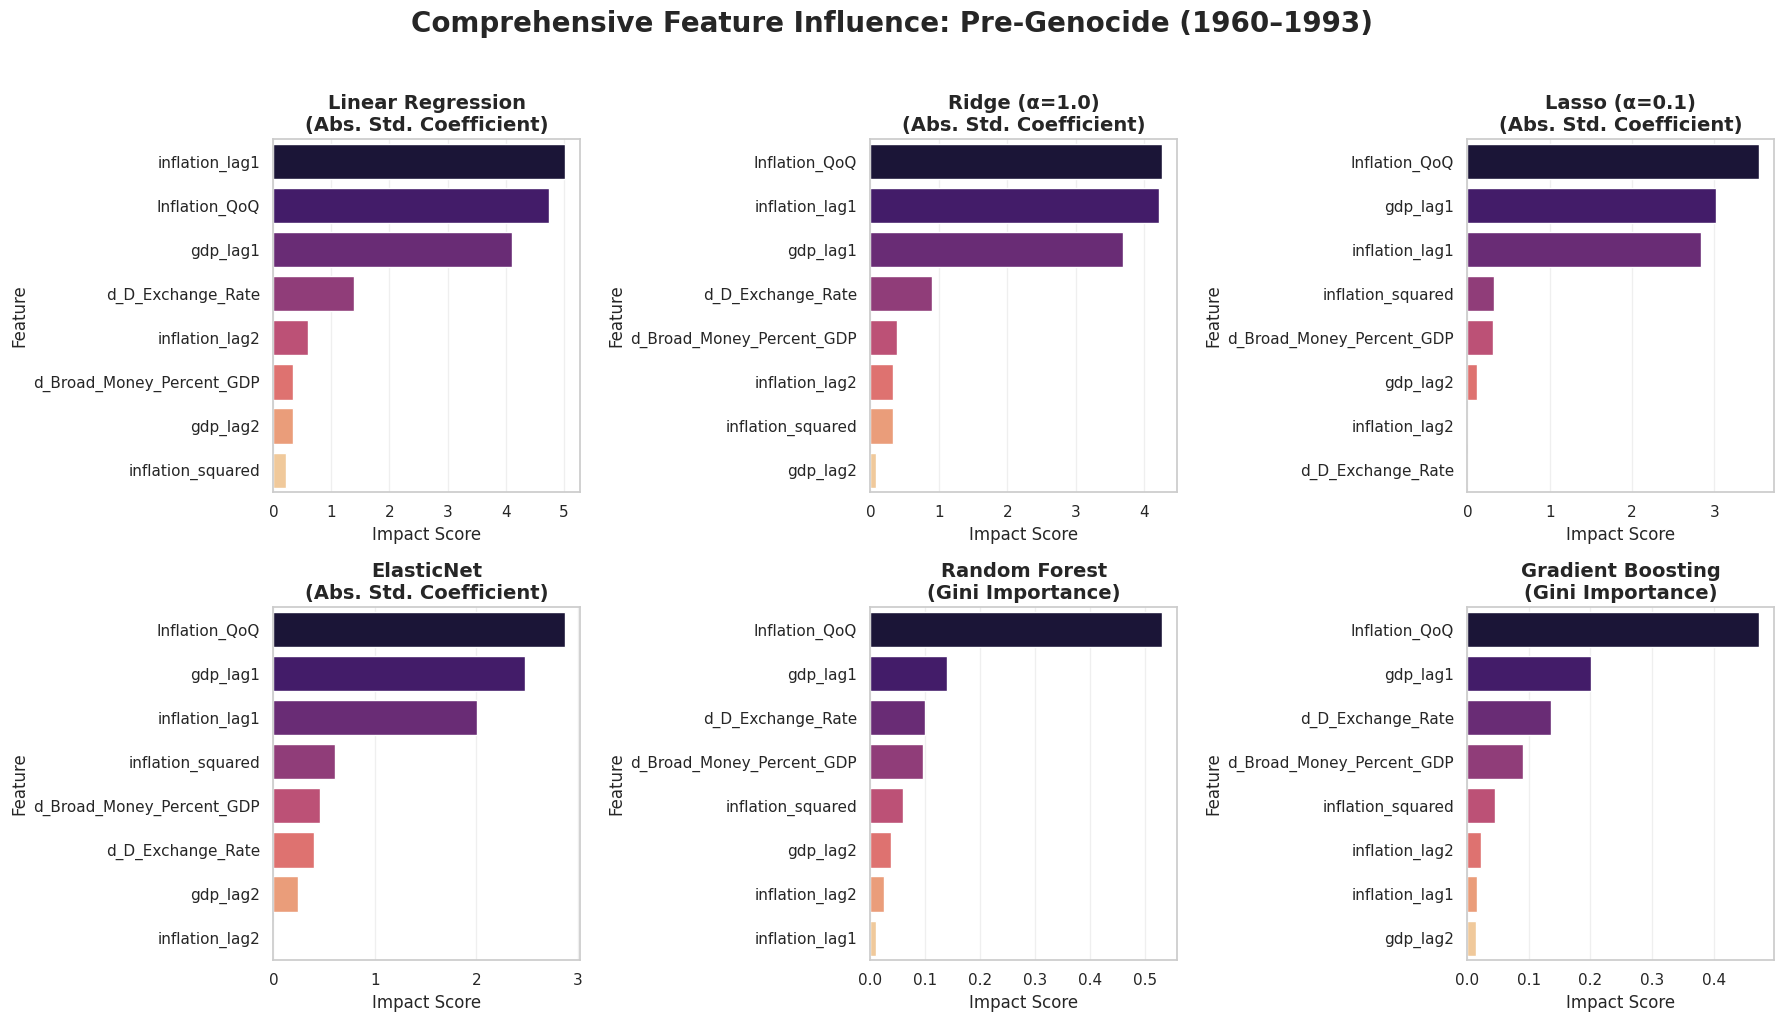

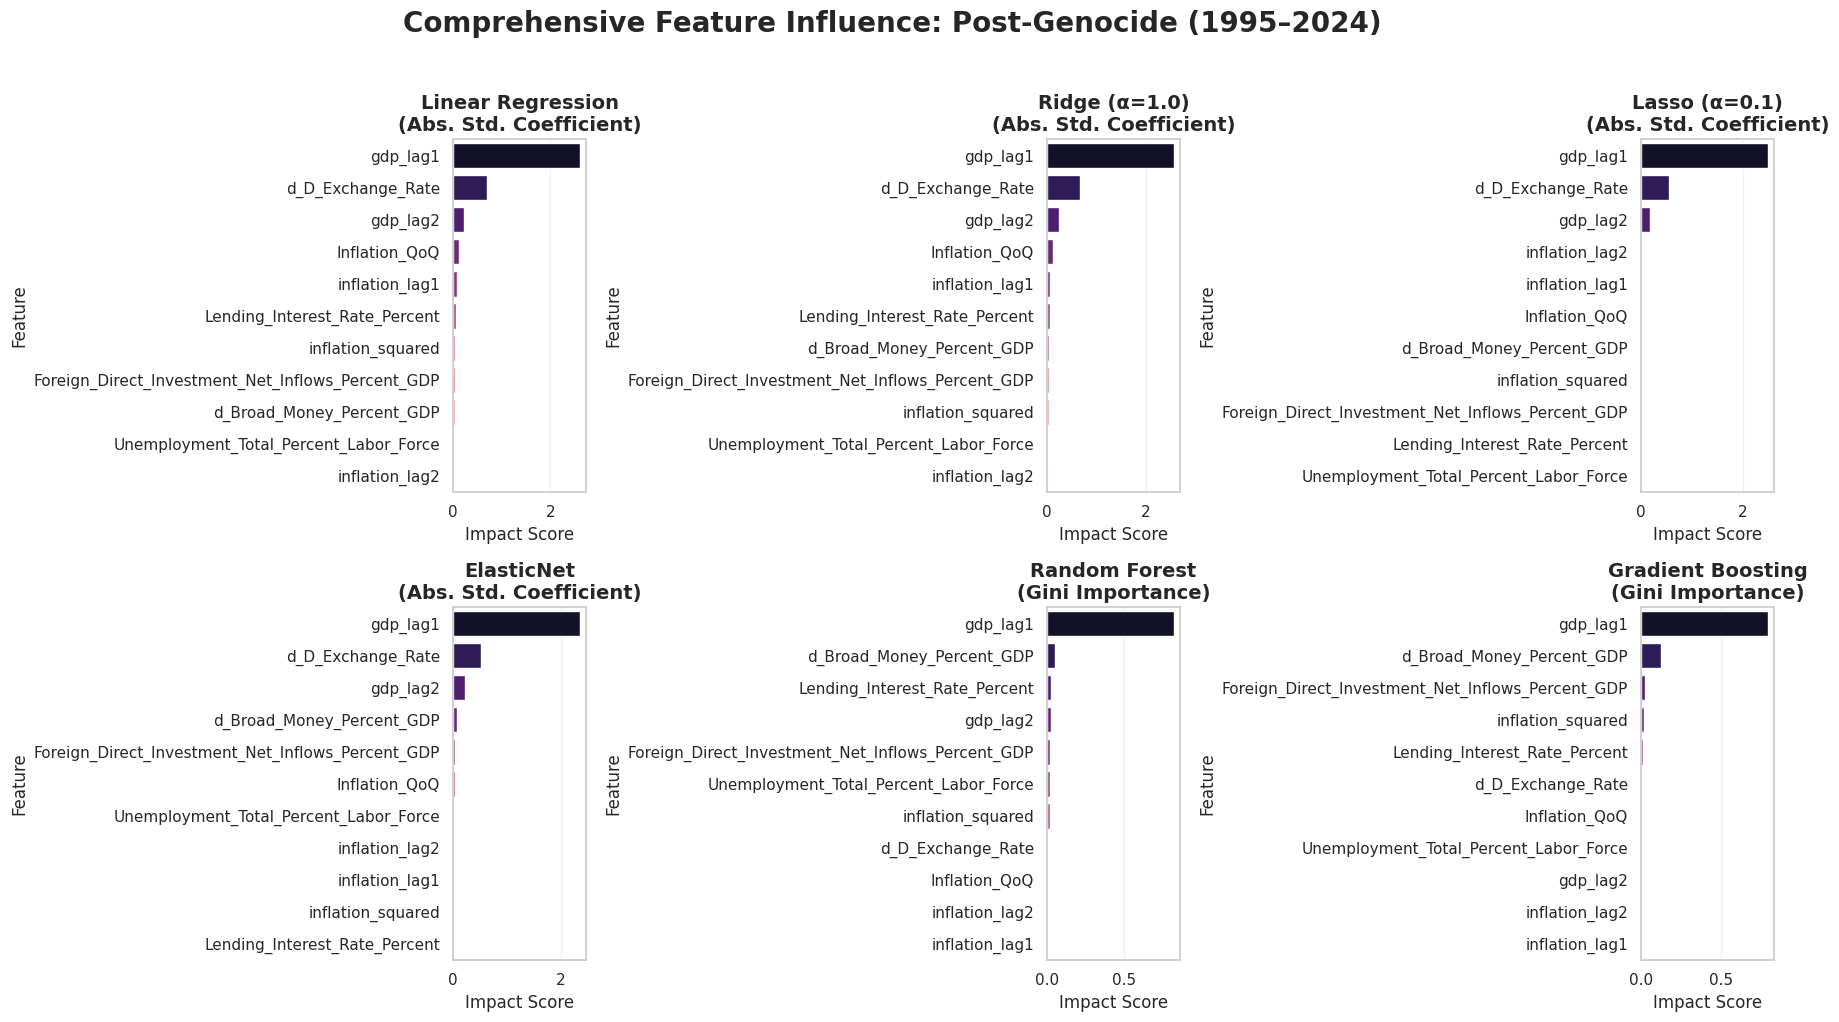

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_master_importances(data, features, target, label, models_dict):
    """
    Standardizes and trains all models to plot their feature influence side-by-side.
    """
    X = data[features]
    y = data[target]

    # 1. Scale for consistency across all plots
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Setup plotting grid
    num_models = len(models_dict)
    cols = 3
    rows = (num_models + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    fig.suptitle(f"Comprehensive Feature Influence: {label}", fontsize=20, fontweight='bold', y=1.02)
    axes = axes.flatten()

    for i, (name, model) in enumerate(models_dict.items()):
        # Fit model on all available data for this era to get the most stable importance
        model.fit(X_scaled, y)

        # Extract importance/coefs
        if hasattr(model, 'feature_importances_'):
            vals = model.feature_importances_
            type_label = "Gini Importance"
        elif hasattr(model, 'coef_'):
            # Standardized coefficients show relative impact magnitude
            vals = np.abs(model.coef_)
            type_label = "Abs. Std. Coefficient"
        else:
            axes[i].axis('off')
            continue

        # Create plot-ready DataFrame
        df_plot = pd.DataFrame({'Feature': features, 'Value': vals}).sort_values('Value', ascending=False)

        sns.barplot(x='Value', y='Feature', data=df_plot, ax=axes[i], palette='magma')
        axes[i].set_title(f"{name}\n({type_label})", fontsize=14, fontweight='semibold')
        axes[i].set_xlabel("Impact Score")
        axes[i].grid(True, axis='x', alpha=0.3)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# --- DEFINING THE FULL MODEL SUITE ---
full_suite = {
    "Linear Regression": LinearRegression(),
    "Ridge (α=1.0)": Ridge(alpha=1.0),
    "Lasso (α=0.1)": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

# --- EXECUTION ---
plot_master_importances(pre_df, PRE_FEATURES_FINAL, TARGET, "Pre-Genocide (1960–1993)", full_suite)
plot_master_importances(post_df, POST_FEATURES_FINAL, TARGET, "Post-Genocide (1995–2024)", full_suite)

# **COMPARISOON ANALYSIS**

In [171]:
all_results = {
    'Linear Regression': linear_results,
    'Ridge': ridge_results,
    'Lasso': lasso_results,
    'ElasticNet': elasticnet_results,
    'Random Forest': rf_results,
    'Gradient Boosting': gb_results
}

def create_thesis_comparison(regime_label):
    # Extract results for the specific regime
    rows = [v[regime_label] for v in all_results.values()]
    df = pd.DataFrame(rows)

    # 2. Reorder and Rename columns to match your "Model Performance Comparison" image
    # We include CV R2 to show scientific rigor, and Test R2/RMSE for performance
    df_final = df[['Model', 'Test RMSE', 'Test R²', 'Test MAE', 'CV R²']].copy()
    df_final.columns = ['Model', 'RMSE (Error)', 'R²', 'MAE (Avg. Error)', 'CV R² (Stability)']

    # Sort by R2 (Best models at the top)
    df_final = df_final.sort_values(by='R²', ascending=False).reset_index(drop=True)
    df_final.index += 1

    print(f"\n--- Model Performance Comparison: {regime_label} ---")
    return df_final

# 3. EXECUTION
pre_final_table = create_thesis_comparison("Pre-Genocide")
post_final_table = create_thesis_comparison("Post-Genocide")

# Display tables
display(pre_final_table)
display(post_final_table)


--- Model Performance Comparison: Pre-Genocide ---

--- Model Performance Comparison: Post-Genocide ---


,Model,RMSE (Error),R²,MAE (Avg. Error),CV R² (Stability)
1,Gradient Boosting,2.0650,0.7441,1.2077,0.6233
2,Random Forest,2.2964,0.6836,1.4474,0.6353
3,Linear Regression,2.4235,0.6476,1.5465,0.7280
4,Ridge,2.5276,0.6167,1.6116,0.7371
5,Lasso,2.6250,0.5866,1.7661,0.7458
6,ElasticNet,2.8644,0.5077,1.9841,0.6912


,Model,RMSE (Error),R²,MAE (Avg. Error),CV R² (Stability)
1,Lasso,0.8793,0.7369,0.7540,0.5518
2,ElasticNet,0.9081,0.7194,0.7206,0.4298
3,Gradient Boosting,0.9166,0.7141,0.7363,-0.1686
4,Random Forest,0.9260,0.7082,0.7492,0.0787
5,Ridge,1.0125,0.6512,0.7232,-0.1594
6,Linear Regression,1.0157,0.6490,0.7211,-2.3028


In [172]:
def style_leaderboard(df, title):
    # Mapping columns to match your reference image style
    df_clean = df[['Model', 'R2 Score', 'RMSE', 'MAE']].copy()
    df_clean.columns = ['Model', 'R²', 'RMSE (Error)', 'MAE (Avg. Error)']

    # Apply Styling
    styled = df_clean.style.set_caption(f"<b>{title}</b>")\
        .background_gradient(cmap='RdYlGn', subset=['R²'])\
        .background_gradient(cmap='RdYlGn_r', subset=['RMSE (Error)', 'MAE (Avg. Error)'])\
        .set_properties(**{'text-align': 'center', 'border': '1px solid black'})\
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#d9d9d9'), ('color', 'black'), ('font-weight', 'bold')]}])\
        .format({'R²': "{:.4f}", 'RMSE (Error)': "{:.4f}", 'MAE (Avg. Error)': "{:.4f}"})

    return styled

# --- EXECUTION ---
# Using the pre_leaderboard and post_leaderboard variables from your previous run
styled_pre = style_leaderboard(pre_leaderboard, "Model Performance Comparison: Pre-Genocide (1960-1993)")
styled_post = style_leaderboard(post_leaderboard, "Model Performance Comparison: Post-Genocide (1995-2024)")

# Display
display(styled_pre)
display(styled_post)

,Model,R²,RMSE (Error),MAE (Avg. Error)
5,Gradient Boosting,0.7576,2.0098,1.1293
4,Random Forest,0.7563,2.0152,1.1322
0,Linear Regression,0.6476,2.4235,1.5465
1,Ridge,0.6167,2.5276,1.6116
2,Lasso,0.5866,2.6250,1.7661
3,ElasticNet,0.5077,2.8644,1.9841


,Model,R²,RMSE (Error),MAE (Avg. Error)
2,Lasso,0.7369,0.8793,0.7540
3,ElasticNet,0.7194,0.9081,0.7206
5,Gradient Boosting,0.7075,0.9272,0.7503
4,Random Forest,0.7009,0.9376,0.7695
1,Ridge,0.6512,1.0125,0.7232
0,Linear Regression,0.6490,1.0157,0.7211


# **MODEL PERFORMANCES**

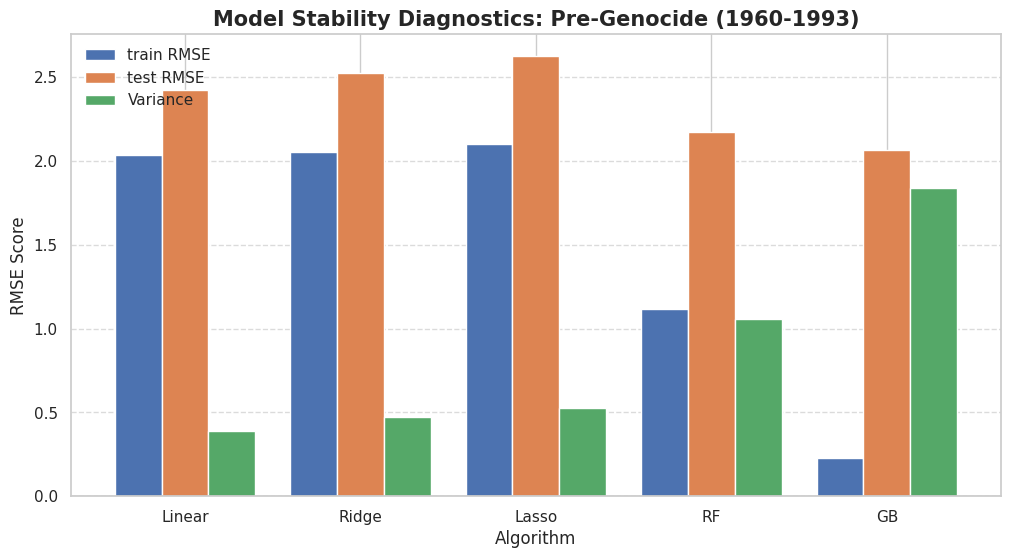

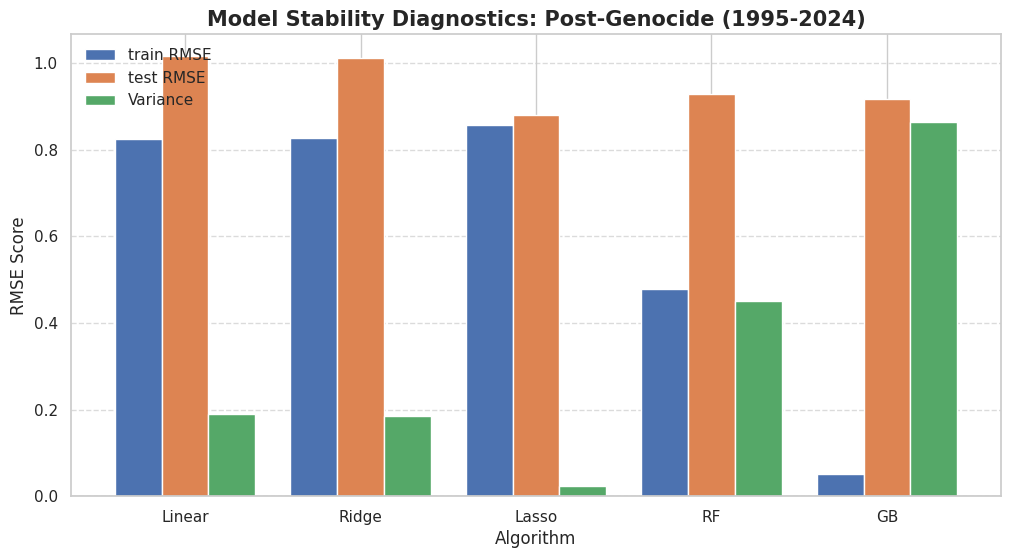

In [173]:
def plot_rmse_diagnostics(data, features, target, label):
    X = data[features].values
    y = data[target].values
    split = int(len(data) * 0.8)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X[:split])
    X_test  = scaler.transform(X[split:])
    y_train, y_test = y[:split], y[split:]

    models = {
        "Linear": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.1),
        "RF": RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
        "GB": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
    }

    plot_data = []
    for name, model in models.items():
        model.fit(X_train, y_train)

        # Calculate Errors
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)

        train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
        test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
        variance = test_rmse - train_rmse # Positive means overfitting

        plot_data.append({
            'Algorithm': name,
            'train RMSE': train_rmse,
            'test RMSE': test_rmse,
            'Variance': variance
        })

    # Create the Plot
    df_plot = pd.DataFrame(plot_data)
    df_plot.set_index('Algorithm').plot(kind='bar', figsize=(12, 6), width=0.8)

    plt.title(f"Model Stability Diagnostics: {label}", fontsize=15, fontweight='bold')
    plt.ylabel("RMSE Score")
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper left')
    plt.axhline(0, color='black', linewidth=0.8) # Zero line for variance
    plt.show()

# --- EXECUTION ---
plot_rmse_diagnostics(pre_df, PRE_FEATURES_FINAL, TARGET, "Pre-Genocide (1960-1993)")
plot_rmse_diagnostics(post_df, POST_FEATURES_FINAL, TARGET, "Post-Genocide (1995-2024)")

In [174]:
# 1. Scale and Fit the Winning Lasso Model
scaler_post = StandardScaler()
X_post_scaled = scaler_post.fit_transform(post_df[POST_FEATURES_FINAL])
y_post = post_df[TARGET]

lasso_win = Lasso(alpha=0.1)
lasso_win.fit(X_post_scaled, y_post)

# 2. Create the Default Coefficient Table
lasso_stats = pd.DataFrame({
    'Variable': POST_FEATURES_FINAL,
    'Coefficient (Beta)': lasso_win.coef_
})

# Filter out variables the Lasso model "killed" (set to zero)
lasso_stats['Status'] = lasso_stats['Coefficient (Beta)'].apply(lambda x: 'Significant' if x != 0 else 'Excluded')
lasso_stats = lasso_stats.sort_values(by='Coefficient (Beta)', key=abs, ascending=False)

print("--- LASSO DEFAULT STATISTICAL OUTPUT (POST-GENOCIDE) ---")
display(lasso_stats.style.bar(subset=['Coefficient (Beta)'], color='#5fba7d'))

--- LASSO DEFAULT STATISTICAL OUTPUT (POST-GENOCIDE) ---


,Variable,Coefficient (Beta),Status
3,gdp_lag1,2.486092,Significant
6,d_D_Exchange_Rate,0.552768,Significant
4,gdp_lag2,0.173107,Significant
2,inflation_lag2,-0.000000,Excluded
1,inflation_lag1,0.000000,Excluded
0,Inflation_QoQ,0.000000,Excluded
5,d_Broad_Money_Percent_GDP,-0.000000,Excluded
7,inflation_squared,0.000000,Excluded
8,Foreign_Direct_Investment_Net_Inflows_Percent_GDP,-0.000000,Excluded
9,Lending_Interest_Rate_Percent,0.000000,Excluded


In [175]:
## FITTING THE GRADUIENT BOOSINT MODLE
X_pre = pre_df[PRE_FEATURES_FINAL]
y_pre = pre_df[TARGET]

gb_win = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
gb_win.fit(X_pre, y_pre)

# 2. Create the Default Importance Table
gb_stats = pd.DataFrame({
    'Variable': PRE_FEATURES_FINAL,
    'Feature Importance Score': gb_win.feature_importances_
}).sort_values(by='Feature Importance Score', ascending=False)

print("--- GB DEFAULT IMPORTANCE OUTPUT (PRE-GENOCIDE) ---")
display(gb_stats.style.background_gradient(cmap='YlGn'))

--- GB DEFAULT IMPORTANCE OUTPUT (PRE-GENOCIDE) ---


,Variable,Feature Importance Score
0,Inflation_QoQ,0.474356
3,gdp_lag1,0.200751
6,d_D_Exchange_Rate,0.138441
5,d_Broad_Money_Percent_GDP,0.092102
7,inflation_squared,0.043742
2,inflation_lag2,0.024031
4,gdp_lag2,0.013719
1,inflation_lag1,0.012857
